In [ ]:
# =============================================================================
# CELL 1 — LOAD + VARIABLE AUDIT (no cleaning, no estimation yet)
# Purpose: pull the main-wave CSV from GitHub into Colab and emit the exact
#          column names so the codebook can be locked against real strings
#          before any share construction or FMLogit runs.
# =============================================================================

import pandas as pd
import re

# -----------------------------------------------------------------------------
# Paste your GitHub URL here. Either form works:
#
# The helper below rewrites a blob URL to its raw equivalent automatically.
# -----------------------------------------------------------------------------
GITHUB_URL = "data url here"

def to_raw(url: str) -> str:
    """Convert a github.com/.../blob/... URL to raw.githubusercontent.com.
    Leaves an already-raw URL untouched."""
    if "raw.githubusercontent.com" in url:
        return url
    m = re.match(r"https://github\.com/(.+?)/blob/(.+)", url)
    if m:
        return f"https://raw.githubusercontent.com/{m.group(1)}/{m.group(2)}"
    return url  # fall through; if it's neither, pandas will raise a clear error

RAW_URL = to_raw(GITHUB_URL)
print(f"Loading from:\n{RAW_URL}\n")

# -----------------------------------------------------------------------------
# Load. We read everything as-is (no dtype coercion) so the audit reflects the
# file exactly. keep_default_na left on; we inspect missingness explicitly next.
# -----------------------------------------------------------------------------
df = pd.read_csv(RAW_URL)

# -----------------------------------------------------------------------------
# Shape + basic integrity signals. These are diagnostics only, not exclusions.
# -----------------------------------------------------------------------------
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}\n")

# Qualtrics often exports 1-2 metadata header rows beneath the real header.
# Flag it so we strip them in the cleaning cell rather than silently modeling them.
print("First cell of first 3 rows (watch for Qualtrics import-id / question-text rows):")
print(df.iloc[:3, 0].tolist(), "\n")

# -----------------------------------------------------------------------------
# THE DELIVERABLE: exact column names, indexed, ready to paste back to me.
# Send this block and I lock every codebook mapping against these literal strings.
# -----------------------------------------------------------------------------
print("=" * 70)
print("COLUMN INVENTORY (index : repr) — copy this whole block back to me")
print("=" * 70)
for i, c in enumerate(df.columns):
    print(f"{i:>3} : {repr(c)}")   # repr() exposes trailing spaces / hidden chars
print("=" * 70)

# Duplicate-name check: pandas silently appends .1 to collisions, which would
# break column references later. Halt-worthy if it fires.
dupes = df.columns[df.columns.duplicated()].tolist()
print(f"\nDuplicate column names (should be empty): {dupes}")

Loading from:
https://raw.githubusercontent.com/jobubabin/istheregodAI/refs/heads/main/IsthereGodhumanusejj.csv?token=GHSAT0AAAAAAEGTZ6BSVTIOMT66EPNIFPPC2UTCZEQ

Rows: 400   Columns: 65

First cell of first 3 rows (watch for Qualtrics import-id / question-text rows):
['134.215.85.129', '98.115.47.233', '69.249.13.141'] 

COLUMN INVENTORY (index : repr) — copy this whole block back to me
  0 : 'IPAddress'
  1 : 'Duration (in seconds)'
  2 : 'RecordedDate'
  3 : 'ResponseId'
  4 : 'LocationLatitude'
  5 : 'LocationLongitude'
  6 : 'PID'
  7 : 'treatment'
  8 : 'read timer_First Click'
  9 : 'read timer_Last Click'
 10 : 'read timer_Page Submit'
 11 : 'read timer_Click Count'
 12 : 'exp timer_First Click'
 13 : 'exp timer_Last Click'
 14 : 'exp timer_Page Submit'
 15 : 'exp timer_Click Count'
 16 : 'allocate1'
 17 : 'allocate2'
 18 : 'allocate3'
 19 : 'timer token First Click'
 20 : 'timer token Last Click'
 21 : 'timer token Page Submit'
 22 : 'timer token Click Count'
 23 : 'why'
 24 : 

In [ ]:
# =============================================================================
# CELL 2 (CONSOLIDATED) — crosswalk + assertions + derived vars, one pass.
# Replaces the old Cell 2 and the 2.2-fix. Builds dir_share etc. so downstream
# cells stop KeyError-ing. No exclusions here.
# =============================================================================
import numpy as np
import pandas as pd

# --- arm vocabulary (Science = reportable label for the 'cosmo' string) ------
ARM_LABELS   = {1: 'Control', 2: 'Science', 3: 'Placebo', 4: 'History'}
TREAT_TO_ARM = {'c': 1, 'cosmo': 2, 'placebo': 3, 'history': 4}

# --- numeric coercion --------------------------------------------------------
alloc_cols  = ['allocate1', 'allocate2', 'allocate3']
likert_cols = ['norms', 'EE1']
ie4_cols    = ['IE-4 LOC_1', 'IE-4 LOC_2', 'IE-4 LOC_3', 'IE-4 LOC_5']
durel_cols  = ['DUREL 1_1', 'DUREL 2', 'durel 3_1', 'durel 3_2', 'durel 3_3']
misc_num    = ['Duration (in seconds)', 'RiskBattery_1', 'Age', 'Age2', 'Total approvals']
for c in alloc_cols + likert_cols + ie4_cols + durel_cols + misc_num:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# --- arm crosswalk + invariant (verified THROUGH the mapping) ----------------
t_str    = df['treatment'].astype(str).str.strip().str.lower()
t_as_arm = t_str.map(TREAT_TO_ARM)
arm_int  = pd.to_numeric(df['arm'], errors='coerce').astype('Int64')
unmapped = df.loc[t_as_arm.isna(), 'treatment'].unique()
assert len(unmapped) == 0, f"Unmapped treatment strings: {unmapped}"
mismatch = df.loc[t_as_arm.values != arm_int.values, ['PID', 'treatment', 'arm']]
assert mismatch.empty, f"treatment vs arm disagree on {len(mismatch)} row(s):\n{mismatch}"
df['arm_int']   = arm_int
df['arm_label'] = df['arm_int'].map(ARM_LABELS)
print("PASS: arm crosswalk consistent.")

# --- shares (DV): fixed map 1=Directed 2=Undirected 3=Unknowable -------------
df['alloc_sum'] = df[alloc_cols].sum(axis=1)
valid_alloc = df['alloc_sum'].round(6) == 100
print(f"Rows with alloc sum != 100: {int((~valid_alloc).sum())}")
df['dir_share']   = np.where(valid_alloc, df['allocate1'] / 100.0, np.nan)
df['undir_share'] = np.where(valid_alloc, df['allocate2'] / 100.0, np.nan)
df['unk_share']   = np.where(valid_alloc, df['allocate3'] / 100.0, np.nan)

# --- moderator scores (built now so later cells have them) -------------------
df['durel_ora']  = df['DUREL 1_1']
df['durel_nora'] = df['DUREL 2']
df['durel_ir']   = df[['durel 3_1', 'durel 3_2', 'durel 3_3']].sum(axis=1, min_count=3)
df['durel_total']= df['durel_ora'] + df['durel_nora'] + df['durel_ir']
df['ie4_internal'] = df[['IE-4 LOC_2', 'IE-4 LOC_3']].mean(axis=1)
df['ie4_external'] = df[['IE-4 LOC_1', 'IE-4 LOC_5']].mean(axis=1)
df['ie4_internality_index'] = pd.concat(
    [df['IE-4 LOC_2'], df['IE-4 LOC_3'], 6 - df['IE-4 LOC_1'], 6 - df['IE-4 LOC_5']],
    axis=1).mean(axis=1)
df['risk_raw']    = df['RiskBattery_1']
df['risk_soep10'] = df['RiskBattery_1'] / 10.0

print(f"dir_share built. Non-null: {df['dir_share'].notna().sum()} / {len(df)}")
print("Derived variables ready. Run Cell 3, then Cell 4.")

PASS: arm crosswalk consistent.
Rows with alloc sum != 100: 0
dir_share built. Non-null: 400 / 400
Derived variables ready. Run Cell 3, then Cell 4.


In [ ]:
# =============================================================================
# CELL 3 — ANALYTIC SAMPLE DEFINITION (reduce to the N=400 main wave)
# No attention-check or speeder exclusions, per your call: mancheck1 and heart
# are NOT used to drop anyone. This cell removes only non-main-wave rows
# (duplicate PIDs / stray soft-launch rows) so the primary estimate runs on the
# intended sample. Nothing here touches allocations or arm outcomes.
# =============================================================================

# --- 3.1  Show current structure so the surplus rows are identifiable ---------
print(f"Rows entering sample definition: {len(df)}")

# Non-unique PIDs: the completed-twice / returned-then-recompleted signature.
dupe_pids = df.loc[df['PID'].duplicated(keep=False)].sort_values('PID')
print(f"\nRows with a non-unique PID: {len(dupe_pids)} "
      f"({int(df['PID'].duplicated().sum())} droppable if we keep one per PID)")
if not dupe_pids.empty:
    print(dupe_pids[['PID', 'RecordedDate', 'arm_label']].to_string(index=False))

# Arm distribution BEFORE removal. Watch whether Science (arm 2) is inflated,
# which would signal demand sub-study rows leaking into the main science arm.
print("\nArm counts before sample definition:")
print(df['arm_label'].value_counts().reindex(list(ARM_LABELS.values())))

# --- 3.2  Define the main-wave analytic sample --------------------------------
# DEFAULT RULE (adjust only if the surplus is not duplication): keep the earliest
# completed submission per PID by RecordedDate. Transparent and auditable; the
# dropped ResponseIds print so the filter is fully documented. Flip keep='last'
# if inspection shows the later submission is the valid completion.
df = df.sort_values('RecordedDate')
before = len(df)
analytic = df.drop_duplicates(subset='PID', keep='first').copy()

dropped = df.loc[~df['ResponseId'].isin(analytic['ResponseId']),
                 ['PID', 'ResponseId', 'RecordedDate', 'arm_label']]
print(f"\nDropped {before - len(analytic)} duplicate-PID row(s):")
if not dropped.empty:
    print(dropped.to_string(index=False))

print(f"\nAnalytic N after de-duplication: {len(analytic)}")
print(analytic['arm_label'].value_counts().reindex(list(ARM_LABELS.values())))

# HALT-style notice if we did not land on the expected main-wave N: the surplus
# is then NOT pure duplication and we filter it explicitly before estimating.
if len(analytic) != 400:
    print(f"\n[!] N={len(analytic)}, expected 400. The surplus is not only "
          f"duplicate PIDs. Tell me what marks the non-main-wave rows "
          f"(a column, a PID list, or the demand subset) and we filter on that "
          f"before the FMLogit.")
else:
    print("\nPASS: landed on N=400. Proceed to estimation.")

Rows entering sample definition: 400

Rows with a non-unique PID: 0 (0 droppable if we keep one per PID)

Arm counts before sample definition:
arm_label
Control    100
Science    100
Placebo    100
History    100
Name: count, dtype: int64

Dropped 0 duplicate-PID row(s):

Analytic N after de-duplication: 400
arm_label
Control    100
Science    100
Placebo    100
History    100
Name: count, dtype: int64

PASS: landed on N=400. Proceed to estimation.


In [ ]:
# =============================================================================
# CELL 4 — PRIMARY FMLOGIT ON DIRECTED SHARE  [DRY RUN ON TEST DATA]
# Fractional logit (Papke & Wooldridge 1996) via GLM Binomial(logit) QMLE.
# DV = dir_share in [0,1]; arm dummies, Control (arm 1) reference; HC3 robust SE.
# Mirrors the LLM Panel A pipeline. AMEs are the reportable quantities.
# NOTE: point estimates here are PROVISIONAL until the clean N=400 is swapped in.
# =============================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- 4.0  Use the de-duplicated frame if it exists, else current df -----------
est = analytic.copy() if 'analytic' in globals() else df.copy()

# Keep only rows with a valid Directed share and a known arm.
est = est.loc[est['dir_share'].notna() & est['arm_int'].notna()].copy()
print(f"Estimation sample: {len(est)} rows  [DRY RUN]")
print(est['arm_label'].value_counts().reindex(list(ARM_LABELS.values())), "\n")

# --- 4.1  Categorical arm with Control as the reference level -----------------
# C(...) with Treatment('Control') makes every coefficient a contrast vs Control,
# exactly parallel to the LLM block's reference coding.
est['arm_label'] = pd.Categorical(
    est['arm_label'], categories=['Control', 'Science', 'Placebo', 'History'])

# --- 4.2  Fractional logit via GLM Binomial(logit), Papke-Wooldridge QMLE -----
# The Binomial family with a continuous [0,1] response IS the fractional-logit
# QMLE; robust (HC) covariance makes it quasi-ML, valid for fractional DV.
model = smf.glm(
    formula="dir_share ~ C(arm_label, Treatment(reference='Control'))",
    data=est,
    family=sm.families.Binomial()
)
fit = model.fit(cov_type='HC3')   # HC3 = human-block analogue of obs-level robust
print(fit.summary())

# --- 4.3  Average Marginal Effects (AMEs) in probability (share) units --------
# For each treatment arm the AME on the Directed share is the average over the
# sample of predicted-share differences, holding the arm switch. With only arm
# dummies this equals the difference in predicted means, but we compute it via
# the margeff machinery so the SE/z/p carry the HC3 covariance through.
ame = fit.get_margeff(dummy=True)
ame_tbl = ame.summary_frame()

# Tidy to match the LLM Panel A layout: arm, AME (pp), SE, z, p.
ame_tbl = ame_tbl.rename(columns={
    'dy/dx': 'AME', 'Std. Err.': 'SE', 'z': 'z', 'Pr(>|z|)': 'p'})
ame_tbl['AME_pp'] = ame_tbl['AME'] * 100     # percentage-point scale, as in LLM table
ame_tbl['SE_pp']  = ame_tbl['SE']  * 100

print("\n" + "=" * 60)
print("PANEL A (HUMAN)  —  AME on Directed share vs Control  [DRY RUN]")
print("=" * 60)
print(ame_tbl[['AME_pp', 'SE_pp', 'z', 'p']].round(4).to_string())
print("=" * 60)
print("Nice")

Estimation sample: 400 rows  [DRY RUN]
arm_label
Control    100
Science    100
Placebo    100
History    100
Name: count, dtype: int64 

                 Generalized Linear Model Regression Results                  
Dep. Variable:              dir_share   No. Observations:                  400
Model:                            GLM   Df Residuals:                      396
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -206.60
Date:                Sat, 29 Aug 2026   Deviance:                       154.36
Time:                        17:26:58   Pearson chi2:                     129.
No. Iterations:                     4   Pseudo R-squ. (CS):          0.0008876
Covariance Type:                  HC3                                         
                                                              coef    std

In [ ]:
# =============================================================================
# CELL 2 — HUMAN FMLOGIT PIPELINE
# Input:  df  (loaded by Cell 1 from GitHub, as-is)
# Steps:  strip Qualtrics junk rows -> map allocations -> harmonize arm ->
#         fractional multinomial logit (Papke-Wooldridge QMLE) ->
#         AMEs on all three shares vs Control -> observation-level bootstrap SEs
# =============================================================================
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm

SEED = 307302   # <-- EDIT if your LLM bootstrap used a different seed
B    = 400      # bootstrap replications (matches LLM protocol)

# ------------------------------------------------- strip Qualtrics header junk
# Raw Qualtrics exports carry 2 extra header rows (question text + ImportId).
# Detect and drop them by requiring Duration to be numeric.
dfh = df.copy()
dur = pd.to_numeric(dfh['Duration (in seconds)'], errors='coerce')
junk = dur.isna().sum()
if junk:
    print(f"Dropping {junk} non-numeric header row(s) (Qualtrics export junk)")
    dfh = dfh[dur.notna()].reset_index(drop=True)

# ---------------------------------------------------------- allocations -> shares
# ASSUMPTION: allocate1=Directed, allocate2=Undirected, allocate3=Unknowable
# (fixed by question ID, not on-screen display order). Verify in Qualtrics.
dfh = dfh.rename(columns={'allocate1': 'directed',
                          'allocate2': 'undirected',
                          'allocate3': 'unknowable'})
for c in ['directed', 'undirected', 'unknowable']:
    dfh[c] = pd.to_numeric(dfh[c])

# ----------------------------------------------------------- harmonize arm labels
if dfh['arm'].dtype == object and dfh['arm'].astype(str).str.isalpha().any():
    dfh['arm'] = dfh['arm'].astype(str).str.strip().str.lower()
else:
    dfh['arm'] = pd.to_numeric(dfh['arm']).map(
        {1: 'control', 2: 'science', 3: 'placebo', 4: 'history'})
ARMS = ['science', 'placebo', 'history']

# ------------------------------------------------------------------ validation
assert dfh['arm'].notna().all(), "unmapped arm values present"
assert set(dfh['arm'].unique()) == {'control','science','placebo','history'}, \
    f"unexpected arm labels: {sorted(dfh['arm'].unique())}"
bad = (dfh[['directed','undirected','unknowable']].sum(axis=1) != 100).sum()
assert bad == 0, f"{bad} rows with allocation sum != 100"
dupes = dfh['PID'].duplicated().sum()
assert dupes == 0, f"{dupes} duplicate PID rows"
print("Rows:", len(dfh), "|", dfh['arm'].value_counts().to_dict())

S_h = dfh[['directed','undirected','unknowable']].values / 100.0

# ------------------------------------------------------------ estimator (QMLE)
def build_design(data, arms=ARMS):
    """Intercept + arm dummies (control = reference)."""
    cols = [np.ones(len(data))]; names = ['const']
    for a in arms:
        cols.append((data['arm'] == a).astype(float).values)
        names.append(f'arm_{a}')
    return np.column_stack(cols), names

def fit_fmlogit(Xmat, Smat):
    """Fractional multinomial logit by QMLE. 3 categories, reference =
    Unknowable. L-BFGS-B with analytic gradient."""
    n, k = Xmat.shape
    def negqll_grad(theta):
        b = theta.reshape(2, k)
        eta = np.column_stack([Xmat @ b.T, np.zeros(n)])
        mx = eta.max(1, keepdims=True)
        ex = np.exp(eta - mx); p = ex / ex.sum(1, keepdims=True)
        f = -(Smat * np.log(np.clip(p, 1e-12, 1))).sum()
        g = np.empty((2, k))
        for j in range(2):
            g[j] = Xmat.T @ (p[:, j] - Smat[:, j])
        return f, g.ravel()
    res = minimize(negqll_grad, np.zeros(2*k), jac=True, method='L-BFGS-B',
                   options={'maxiter': 20000, 'maxfun': 50000,
                            'ftol': 1e-12, 'gtol': 1e-8})
    return res.x.reshape(2, k), res

def predict_all(Xmat, beta):
    eta = np.column_stack([Xmat @ beta.T, np.zeros(len(Xmat))])
    mx = eta.max(1, keepdims=True)
    p = np.exp(eta - mx); p /= p.sum(1, keepdims=True)
    return p  # cols: directed, undirected, unknowable

def ame_table(data, beta):
    """AME on each share (pp), each arm vs control, averaged over sample."""
    base = data.copy(); base['arm'] = 'control'
    Xb, _ = build_design(base)
    p0 = predict_all(Xb, beta).mean(0)
    out = {}
    for a in ARMS:
        cf = data.copy(); cf['arm'] = a
        Xa, _ = build_design(cf)
        out[a] = (predict_all(Xa, beta).mean(0) - p0) * 100
    return out

# ------------------------------------------------------------------- point fit
X_h, names_h = build_design(dfh)
beta_h, res_h = fit_fmlogit(X_h, S_h)
print("converged:", res_h.success, "| log-QL:", f"{-res_h.fun:.1f}",
      "| grad norm:", f"{np.linalg.norm(res_h.jac):.2e}")
ames = ame_table(dfh, beta_h)

# ---------------------------------------------------- bootstrap (obs-level SEs)
rng = np.random.default_rng(SEED)
boot = {a: [] for a in ARMS}
n = len(dfh); fails = 0
for b in range(B):
    idx = rng.integers(0, n, n)
    d_b = dfh.iloc[idx].reset_index(drop=True)
    S_b = d_b[['directed','undirected','unknowable']].values / 100.0
    X_b, _ = build_design(d_b)
    beta_b, r_b = fit_fmlogit(X_b, S_b)
    if not r_b.success:
        fails += 1; continue
    a_b = ame_table(d_b, beta_b)
    for a in ARMS:
        boot[a].append(a_b[a])
print(f"bootstrap: {B - fails}/{B} successful replications")

# --------------------------------------------------------------------- results
CATS = ['Directed', 'Undirected', 'Unknowable']
print("\n" + "="*76)
print("PANEL A (HUMAN) - AME on shares vs Control, FMLogit, bootstrap SEs")
print("="*76)
print(f"{'arm':<10}" + "".join(f"{c:>22}" for c in CATS))
latex_rows = []
for a in ARMS:
    bs = np.array(boot[a])
    se = bs.std(axis=0, ddof=1)
    z  = ames[a] / se
    p  = 2 * (1 - norm.cdf(np.abs(z)))
    cells = "  ".join(f"{ames[a][j]:+7.2f} ({se[j]:.2f})" for j in range(3))
    print(f"{a:<10} {cells}")
    stars = ["***" if pv < .001 else "**" if pv < .01 else "*" if pv < .05
             else "" for pv in p]
    latex_rows.append(
        f"{a.capitalize()} & " +
        " & ".join(f"${ames[a][j]:+.2f}^{{{stars[j]}}}$" for j in range(3)) +
        r" \\" + "\n  & " +
        " & ".join(f"$({se[j]:.2f})$" for j in range(3)) + r" \\[2pt]")

print("\n% ---- paste into human Panel A ----")
print("\n".join(latex_rows))

# ---------------------------------------------------------- descriptives + checks
print("\nRaw mean allocations by arm (for descriptive table):")
print(dfh.groupby('arm')[['directed','undirected','unknowable']]
        .mean().round(2).reindex(['control','science','placebo','history']))
for a in ARMS:
    print(f"sum-to-zero check {a}: {ames[a].sum():+.4f}")

Rows: 400 | {'placebo': 100, 'history': 100, 'control': 100, 'science': 100}
converged: True | log-QL: -434.4 | grad norm: 2.33e-05
bootstrap: 400/400 successful replications

PANEL A (HUMAN) - AME on shares vs Control, FMLogit, bootstrap SEs
arm                     Directed            Undirected            Unknowable
science      -2.39 (3.82)    +1.90 (3.64)    +0.49 (3.12)
placebo      +0.95 (4.10)    +1.37 (3.44)    -2.32 (3.09)
history      +1.39 (2.60)    -1.01 (2.92)    -0.38 (2.53)

% ---- paste into human Panel A ----
Science & $-2.39^{}$ & $+1.90^{}$ & $+0.49^{}$ \\
  & $(3.82)$ & $(3.64)$ & $(3.12)$ \\[2pt]
Placebo & $+0.95^{}$ & $+1.37^{}$ & $-2.32^{}$ \\
  & $(4.10)$ & $(3.44)$ & $(3.09)$ \\[2pt]
History & $+1.39^{}$ & $-1.01^{}$ & $-0.38^{}$ \\
  & $(2.60)$ & $(2.92)$ & $(2.53)$ \\[2pt]

Raw mean allocations by arm (for descriptive table):
         directed  undirected  unknowable
arm                                      
control     40.74       29.32       29.94
science  

In [ ]:
# =============================================================================
# CELL 5 — DESCRIPTIVE STATISTICS on allocation token counts (0-100 scale)
# Means + SDs for the three categories: aggregate, by arm, by sex.
# Restricted to valid constant-sum rows so descriptives match the DV sample.
# NOTE: SD here is dispersion for the TABLE. The figure (Cell 6) uses SE = SD/sqrt(n)
#       for error bars. Keeping the two separate on purpose; do not conflate them.
# =============================================================================
import numpy as np
import pandas as pd

# --- analysis frame: same construction as the FMLogit sample -----------------
est = analytic.copy() if 'analytic' in globals() else df.copy()
est = est.loc[(est['alloc_sum'].round(6) == 100) & est['arm_int'].notna()].copy()
print(f"Descriptive sample: {len(est)} rows\n")

CATS = {'allocate1': 'Directed', 'allocate2': 'Undirected', 'allocate3': 'Unknowable'}
ARM_ORDER = ['Control', 'Science', 'Placebo', 'History']

def describe_alloc(frame, by=None):
    """Return mean / SD / n / SE per allocation category, optionally within groups.
    SE = SD / sqrt(n), reported so the same table can feed both prose and figure."""
    d = frame.rename(columns=CATS)
    catnames = list(CATS.values())
    if by is None:
        out = d[catnames].agg(['mean', 'std', 'count']).T
        out.columns = ['mean', 'sd', 'n']
        out['se'] = out['sd'] / np.sqrt(out['n'])
        return out.round(3)
    rows = []
    for key, sub in d.groupby(by, observed=True):
        for c in catnames:
            s = sub[c].dropna()
            rows.append({by: key, 'category': c, 'mean': s.mean(),
                         'sd': s.std(), 'n': int(s.count()),
                         'se': s.std() / np.sqrt(s.count())})
    return pd.DataFrame(rows)

# --- 5.1  AGGREGATE (pooled across all arms) ---------------------------------
print("=" * 55)
print("AGGREGATE  —  mean / SD / n / SE per category (all arms pooled)")
print("=" * 55)
print(describe_alloc(est).to_string())

# --- 5.2  BY ARM (also the input to the clustered bar chart) -----------------
by_arm = describe_alloc(est, by='arm_label')
by_arm['arm_label'] = pd.Categorical(by_arm['arm_label'], categories=ARM_ORDER, ordered=True)
by_arm = by_arm.sort_values(['arm_label', 'category']).reset_index(drop=True)
print("\n" + "=" * 55)
print("BY ARM  —  mean / SD / n / SE per category")
print("=" * 55)
print(by_arm.round(3).to_string(index=False))

# --- 5.3  BY SEX (Prolific-coded). Inspect values first, then split ----------
print("\nSex column values present:")
print(est['Sex'].astype(str).str.strip().value_counts(dropna=False).to_string())

by_sex = describe_alloc(est, by='Sex')
print("\n" + "=" * 55)
print("BY SEX  —  mean / SD / n / SE per category")
print("=" * 55)
print(by_sex.round(3).to_string(index=False))
# If any non Male/Female categories appear above, they are shown separately
# rather than silently dropped; decide their handling before the manuscript table.

Descriptive sample: 400 rows

AGGREGATE  —  mean / SD / n / SE per category (all arms pooled)
              mean      sd      n     se
Directed    40.728  27.947  400.0  1.397
Undirected  29.885  24.077  400.0  1.204
Unknowable  29.388  21.982  400.0  1.099

BY ARM  —  mean / SD / n / SE per category
arm_label   category  mean     sd   n    se
  Control   Directed 40.74 18.079 100 1.808
  Control Undirected 29.32 19.827 100 1.983
  Control Unknowable 29.94 17.364 100 1.736
  Science   Directed 38.35 34.039 100 3.404
  Science Undirected 31.22 27.958 100 2.796
  Science Unknowable 30.43 26.273 100 2.627
  Placebo   Directed 41.69 35.602 100 3.560
  Placebo Undirected 30.69 26.695 100 2.669
  Placebo Unknowable 27.62 25.443 100 2.544
  History   Directed 42.13 19.649 100 1.965
  History Undirected 28.31 21.066 100 2.107
  History Unknowable 29.56 17.427 100 1.743

Sex column values present:
Sex
Female    206
Male      194

BY SEX  —  mean / SD / n / SE per category
   Sex   category   me

WELCH ANOVA (unequal variance) across arms, per category

[!] Unexpected welch_anova columns for Directed: ['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']
   Source  ddof1      ddof2        F    p_unc      np2
arm_label      3 212.715125 0.328939 0.804435 0.002742

[!] Unexpected welch_anova columns for Undirected: ['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']
   Source  ddof1      ddof2        F    p_unc      np2
arm_label      3 217.978024 0.297309 0.827323 0.002261

[!] Unexpected welch_anova columns for Unknowable: ['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']
   Source  ddof1      ddof2        F   p_unc      np2
arm_label      3 216.583035 0.244023 0.86553 0.002358


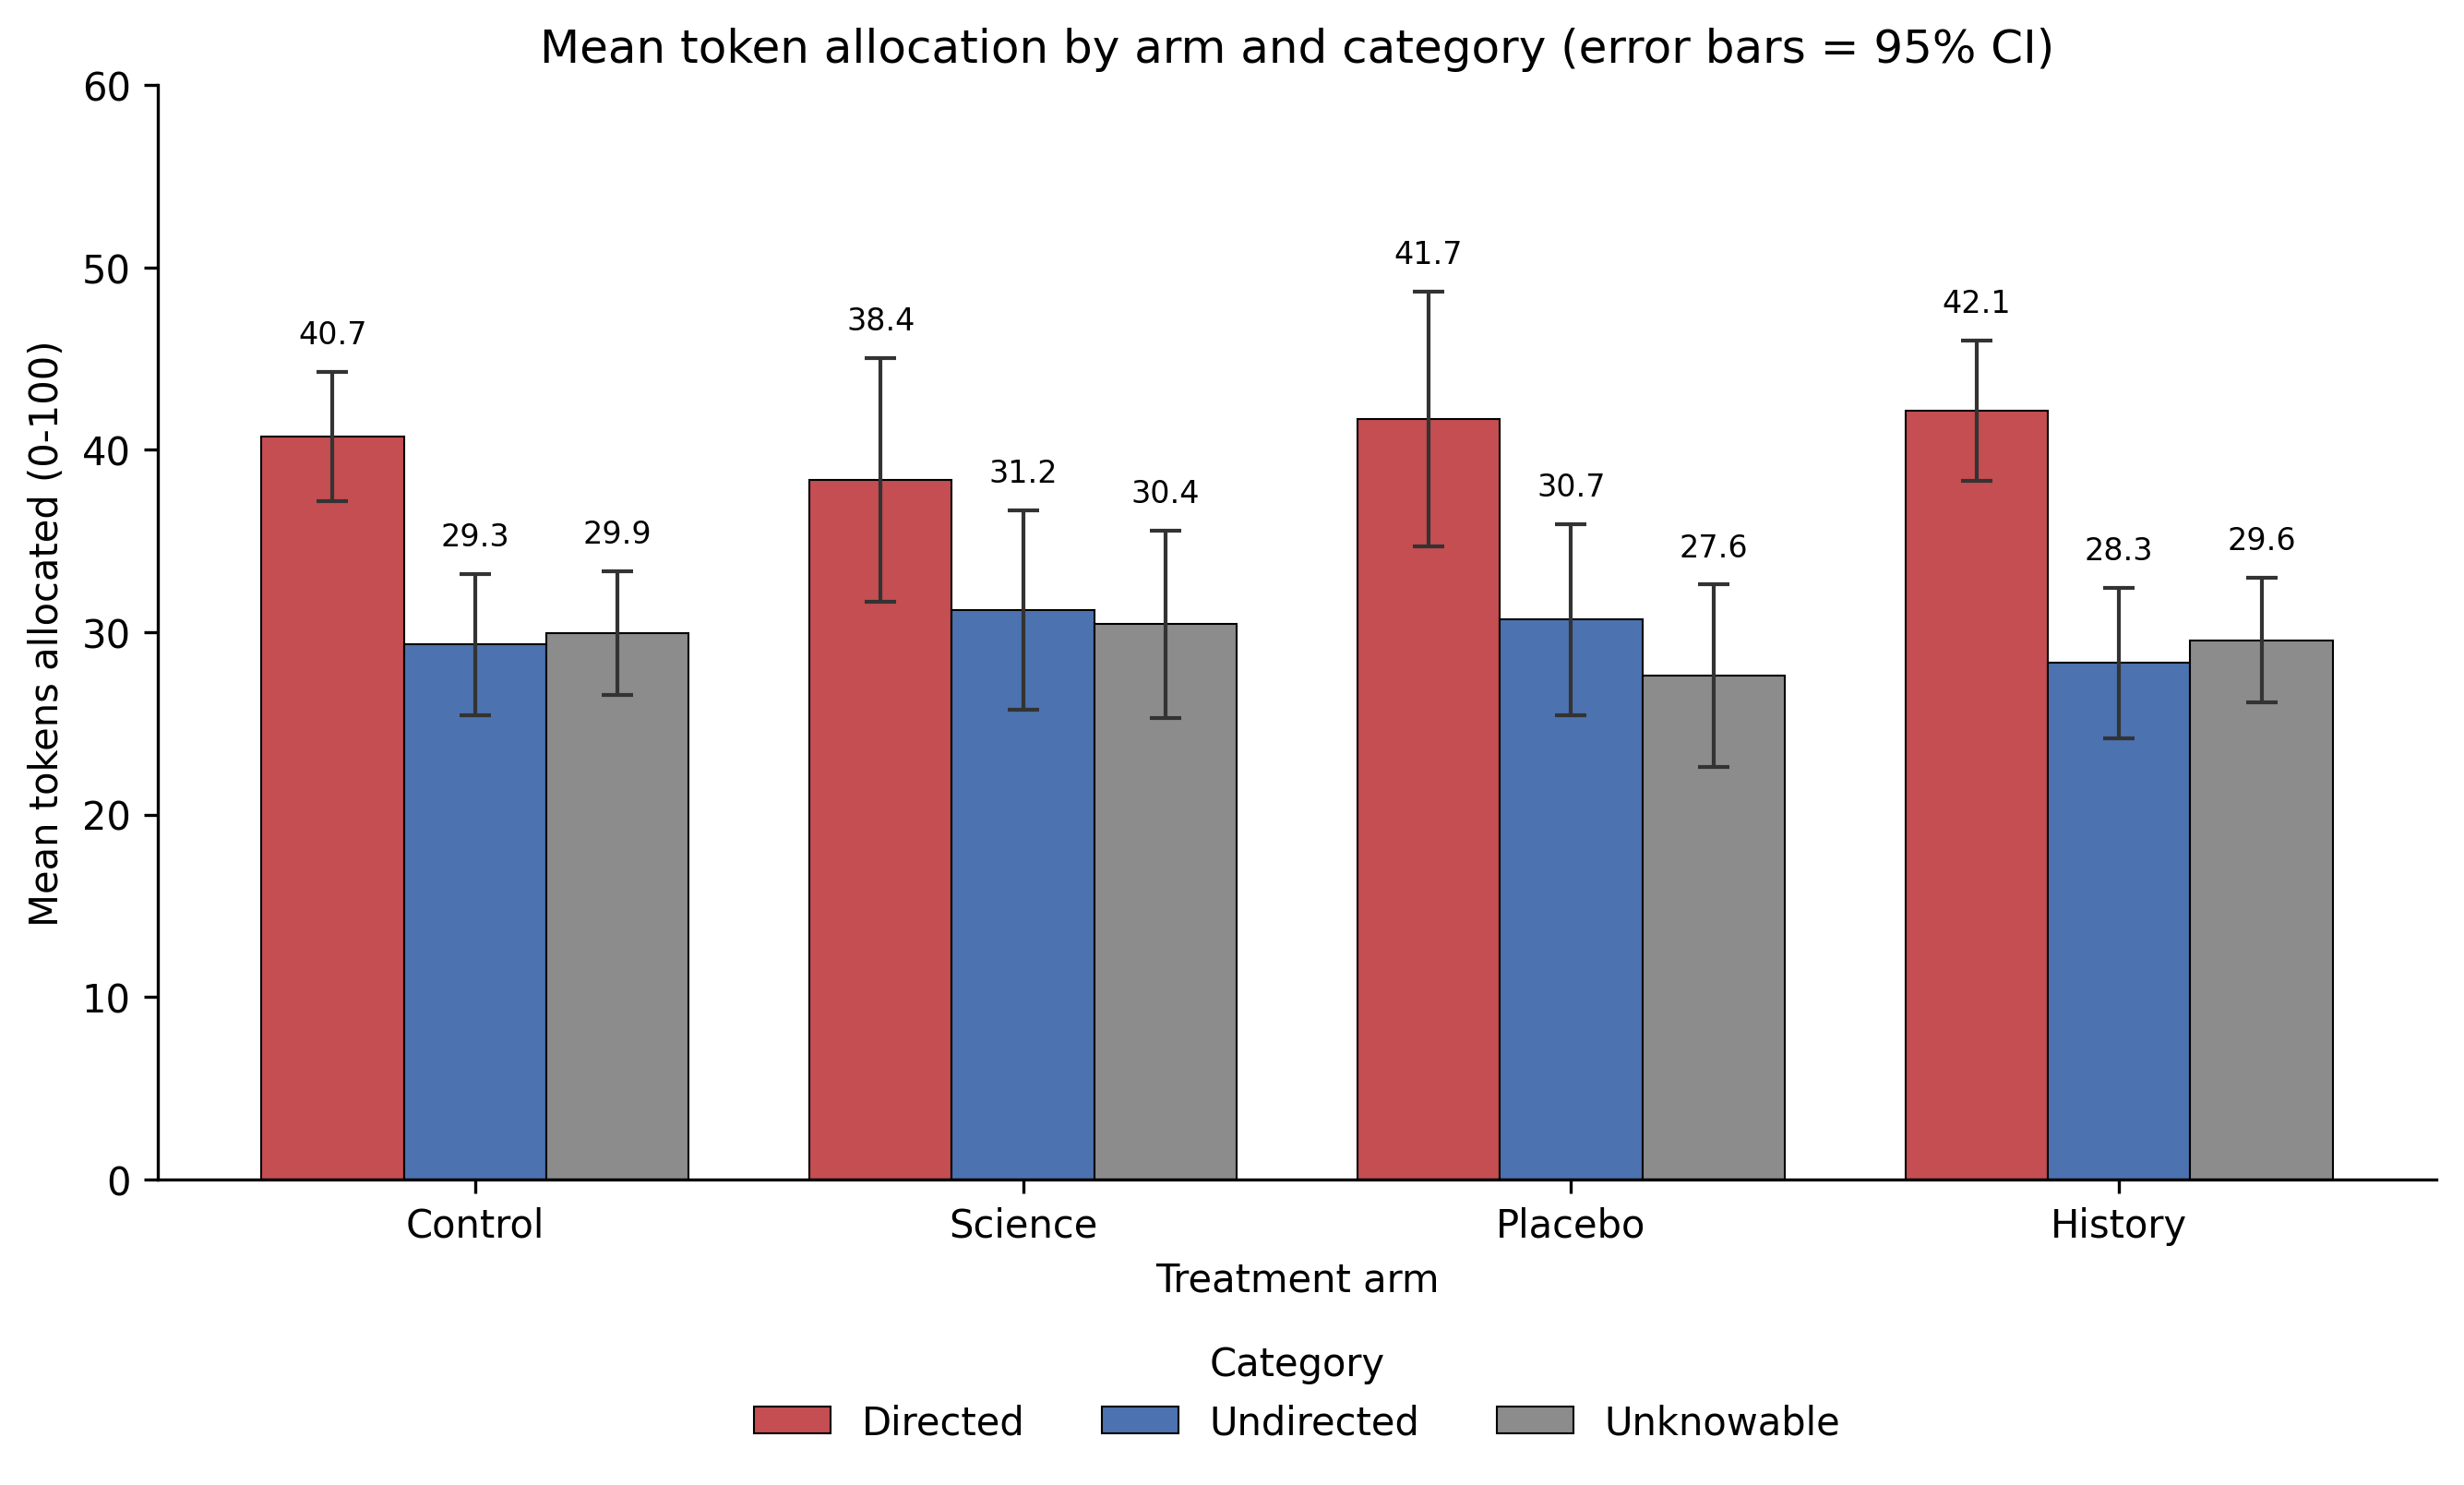


Saved: fig_arm_means_ci.png


In [ ]:
# =============================================================================
# CELL 6 (REVISED) — clustered bars with 95% CI + Welch ANOVA + Games-Howell
# Error bars now = 1.96*SE (approx 95% CI for the mean) so visual overlap maps
# roughly onto a 5% test; the FORMAL test is Welch ANOVA per category across
# arms with Games-Howell post-hoc, same as the LLM figure. Run Cell 5 first.
# =============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# pingouin carries welch_anova + pairwise_gameshowell; install if absent.
try:
    import pingouin as pg
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pingouin"])
    import pingouin as pg

CAT_ORDER = ['Directed', 'Undirected', 'Unknowable']
CAT_COLOR = {'Directed': '#C44E52', 'Undirected': '#4C72B0', 'Unknowable': '#8C8C8C'}
ARM_ORDER = ['Control', 'Science', 'Placebo', 'History']

# frame with named category columns for the tests
estc = est.rename(columns=CATS).copy()
estc['arm_label'] = pd.Categorical(estc['arm_label'], categories=ARM_ORDER, ordered=True)

# --- 6.1  FORMAL TESTS: Welch ANOVA + Games-Howell, per category -------------
# Version-robust column access: pingouin has labeled the p column 'p-unc' or 'p'
# across releases, and ddof1/ddof2 naming has shifted too. We locate columns by
# pattern rather than hardcoding, so this survives the version difference.
print("=" * 62)
print("WELCH ANOVA (unequal variance) across arms, per category")
print("=" * 62)

def _pick(cols, *cands):
    """Return the first candidate present in cols (exact, then case-insensitive)."""
    for c in cands:
        if c in cols:
            return c
    low = {c.lower(): c for c in cols}
    for c in cands:
        if c.lower() in low:
            return low[c.lower()]
    return None

gh_all = {}
for cat in CAT_ORDER:
    sub = estc[['arm_label', cat]].dropna()
    wa = pg.welch_anova(data=sub, dv=cat, between='arm_label')
    cols = wa.columns.tolist()

    p_col   = _pick(cols, 'p-unc', 'p')
    dfn_col = _pick(cols, 'ddof1', 'DF1', 'df1')
    dfd_col = _pick(cols, 'ddof2', 'DF2', 'df2')
    F_col   = _pick(cols, 'F')

    # Fallback: if any name lookup failed, show what pingouin returned and stop
    # so we map to the real columns rather than guessing.
    if None in (p_col, dfn_col, dfd_col, F_col):
        print(f"\n[!] Unexpected welch_anova columns for {cat}: {cols}")
        print(wa.to_string(index=False))
        continue

    F, dfn, dfd, p = wa.loc[0, [F_col, dfn_col, dfd_col, p_col]]
    star = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
    print(f"\n{cat:11s}: F({dfn:.0f},{dfd:.1f})={F:6.2f}  p={p:.4g}  {star}")

    gh = pg.pairwise_gameshowell(data=sub, dv=cat, between='arm_label')
    gh_all[cat] = gh
    # Games-Howell p column has also varied: 'pval' vs 'p-tukey' in some builds
    gh_p = _pick(gh.columns.tolist(), 'pval', 'p-tukey', 'p-unc', 'p')
    sig = gh.loc[gh[gh_p] < .05, ['A', 'B', 'diff', 'se', gh_p]]
    if sig.empty:
        print("   no arm pair separates at p<.05")
    else:
        for _, r in sig.iterrows():
            print(f"   {r['A']:8s} vs {r['B']:8s}: diff={r['diff']:+6.2f}  p={r[gh_p]:.4g}")

# --- 6.2  FIGURE: clustered bars, 95% CI caps --------------------------------
by_arm = describe_alloc(est, by='arm_label')
by_arm['arm_label'] = pd.Categorical(by_arm['arm_label'], categories=ARM_ORDER, ordered=True)
M  = by_arm.pivot(index='arm_label', columns='category', values='mean').reindex(ARM_ORDER)[CAT_ORDER]
SE = by_arm.pivot(index='arm_label', columns='category', values='se').reindex(ARM_ORDER)[CAT_ORDER]
CI = SE * 1.96   # approximate 95% CI half-width

x, width = np.arange(len(ARM_ORDER)), 0.26
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)
for i, cat in enumerate(CAT_ORDER):
    off = (i - 1) * width
    ax.bar(x + off, M[cat].values, width, yerr=CI[cat].values, capsize=4,
           color=CAT_COLOR[cat], edgecolor='black', linewidth=0.5, label=cat,
           error_kw={'elinewidth': 1, 'ecolor': '#333333'})
    for xi, m, ci in zip(x + off, M[cat].values, CI[cat].values):
        ax.text(xi, m + ci + 1.2, f"{m:.1f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(ARM_ORDER)
ax.set_ylabel('Mean tokens allocated (0-100)'); ax.set_xlabel('Treatment arm')
ax.set_title('Mean token allocation by arm and category (error bars = 95% CI)')
ax.set_ylim(0, max((M + CI).values.max() + 8, 60))
ax.legend(title='Category', frameon=False, ncol=3, loc='upper center',
          bbox_to_anchor=(0.5, -0.12))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('fig_arm_means_ci.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: fig_arm_means_ci.png")

In [ ]:
# --- 6.1  FORMAL TESTS: Welch ANOVA + Games-Howell, per category -------------
# Version-robust column access: pingouin has labeled the p column 'p-unc' or 'p'
# across releases, and ddof1/ddof2 naming has shifted too. We locate columns by
# pattern rather than hardcoding, so this survives the version difference.
print("=" * 62)
print("WELCH ANOVA (unequal variance) across arms, per category")
print("=" * 62)

def _pick(cols, *cands):
    """Return the first candidate present in cols (exact, then case-insensitive)."""
    for c in cands:
        if c in cols:
            return c
    low = {c.lower(): c for c in cols}
    for c in cands:
        if c.lower() in low:
            return low[c.lower()]
    return None

gh_all = {}
for cat in CAT_ORDER:
    sub = estc[['arm_label', cat]].dropna()
    wa = pg.welch_anova(data=sub, dv=cat, between='arm_label')
    cols = wa.columns.tolist()

    p_col   = _pick(cols, 'p-unc', 'p')
    dfn_col = _pick(cols, 'ddof1', 'DF1', 'df1')
    dfd_col = _pick(cols, 'ddof2', 'DF2', 'df2')
    F_col   = _pick(cols, 'F')

    # Fallback: if any name lookup failed, show what pingouin returned and stop
    # so we map to the real columns rather than guessing.
    if None in (p_col, dfn_col, dfd_col, F_col):
        print(f"\n[!] Unexpected welch_anova columns for {cat}: {cols}")
        print(wa.to_string(index=False))
        continue

    F, dfn, dfd, p = wa.loc[0, [F_col, dfn_col, dfd_col, p_col]]
    star = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
    print(f"\n{cat:11s}: F({dfn:.0f},{dfd:.1f})={F:6.2f}  p={p:.4g}  {star}")

    gh = pg.pairwise_gameshowell(data=sub, dv=cat, between='arm_label')
    gh_all[cat] = gh
    # Games-Howell p column has also varied: 'pval' vs 'p-tukey' in some builds
    gh_p = _pick(gh.columns.tolist(), 'pval', 'p-tukey', 'p-unc', 'p')
    sig = gh.loc[gh[gh_p] < .05, ['A', 'B', 'diff', 'se', gh_p]]
    if sig.empty:
        print("   no arm pair separates at p<.05")
    else:
        for _, r in sig.iterrows():
            print(f"   {r['A']:8s} vs {r['B']:8s}: diff={r['diff']:+6.2f}  p={r[gh_p]:.4g}")

WELCH ANOVA (unequal variance) across arms, per category

[!] Unexpected welch_anova columns for Directed: ['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']
   Source  ddof1      ddof2        F    p_unc      np2
arm_label      3 212.715125 0.328939 0.804435 0.002742

[!] Unexpected welch_anova columns for Undirected: ['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']
   Source  ddof1      ddof2        F    p_unc      np2
arm_label      3 217.978024 0.297309 0.827323 0.002261

[!] Unexpected welch_anova columns for Unknowable: ['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']
   Source  ddof1      ddof2        F   p_unc      np2
arm_label      3 216.583035 0.244023 0.86553 0.002358


Sex values present: {'Female': 206, 'Male': 194}


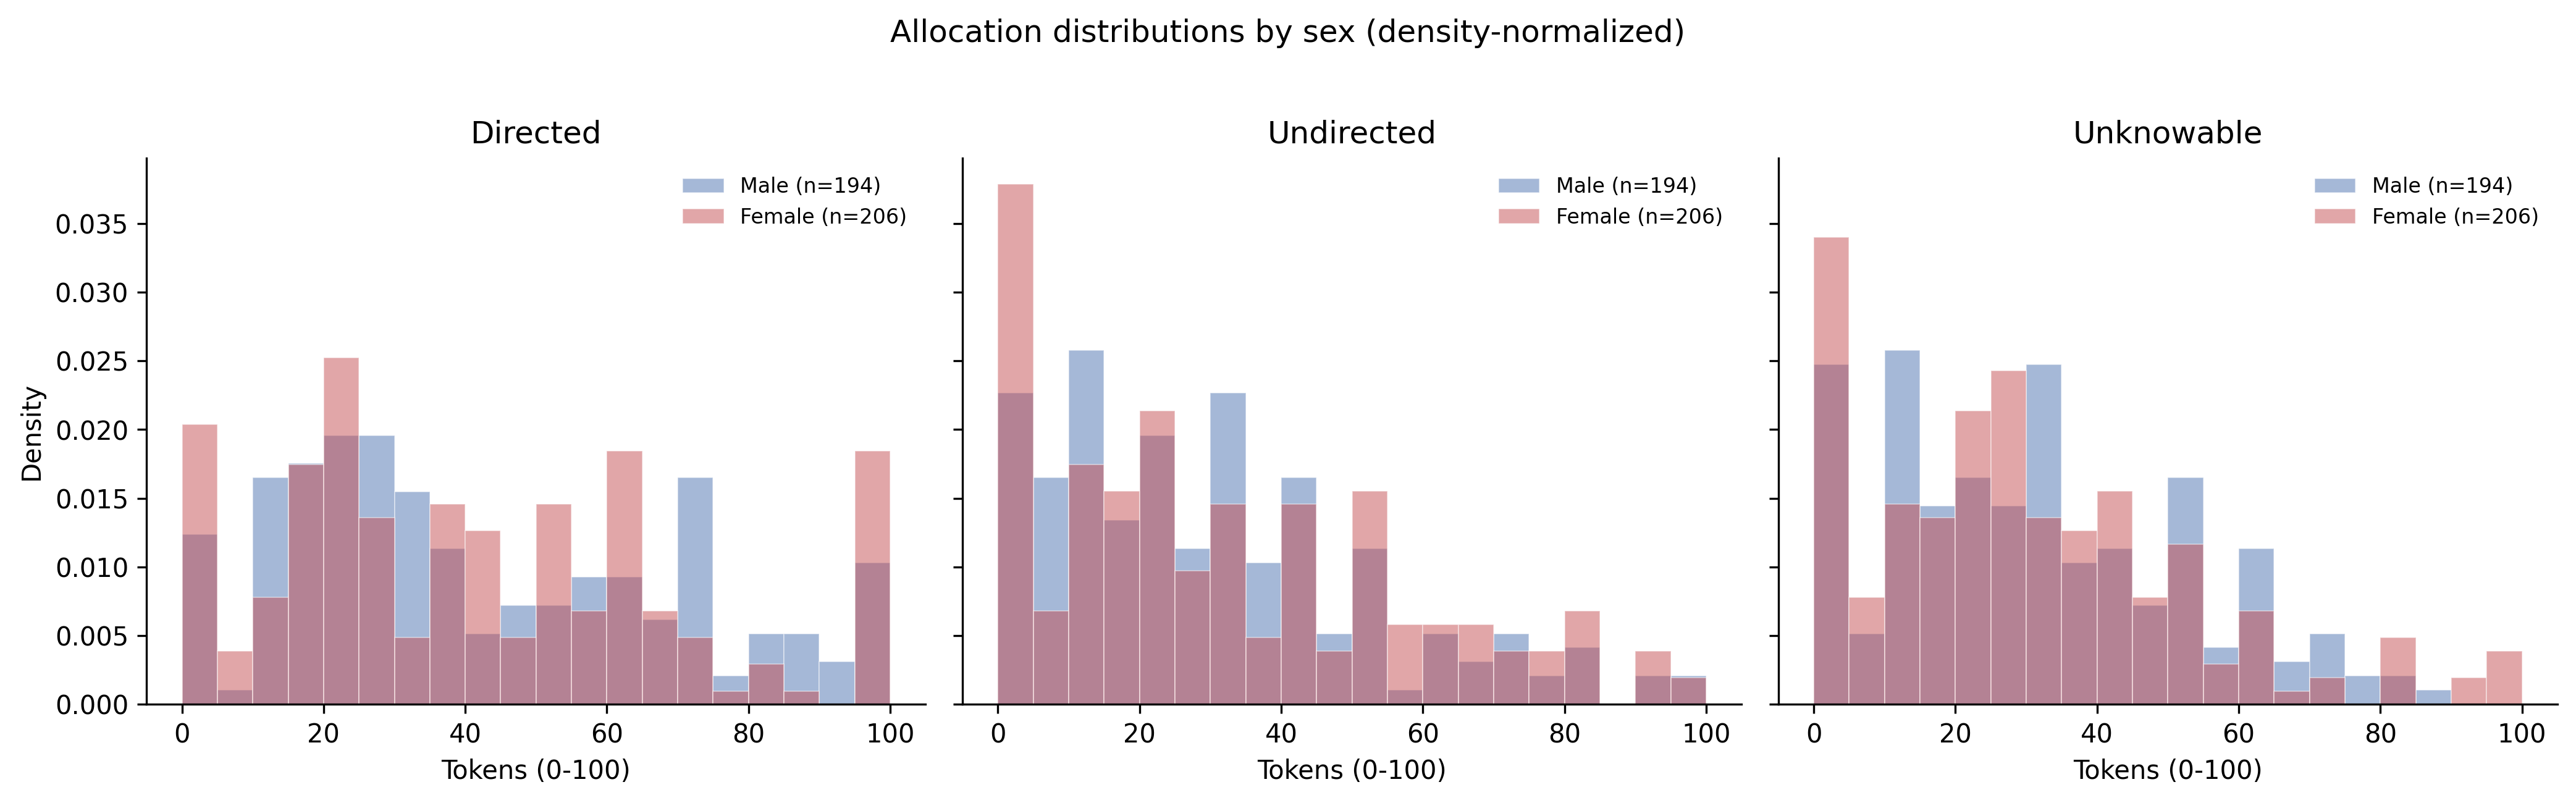

Saved: fig_hist_by_sex.png


In [ ]:
# =============================================================================
# CELL 7 — HISTOGRAMS of token allocation by sex, one panel per category
# Male vs Female overlaid. density=True so shapes compare fairly despite unequal
# n. This is where the predicted bimodality should be visible (mass at 0 and 100
# on Directed/Undirected rather than a central hump).
# =============================================================================
import numpy as np, matplotlib.pyplot as plt

sx = est['Sex'].astype(str).str.strip().str.capitalize()
print("Sex values present:", sx.value_counts(dropna=False).to_dict())

keep = sx.isin(['Male', 'Female'])          # non-binary/other shown separately if present
plot_df = est.loc[keep].rename(columns=CATS).copy()
plot_df['Sex'] = sx[keep].values

SEX_COLOR = {'Male': '#4C72B0', 'Female': '#C44E52'}
bins = np.arange(0, 105, 5)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), dpi=300, sharey=True)
for ax, cat in zip(axes, CAT_ORDER):
    for s in ['Male', 'Female']:
        vals = plot_df.loc[plot_df['Sex'] == s, cat].dropna()
        ax.hist(vals, bins=bins, density=True, alpha=0.5, color=SEX_COLOR[s],
                edgecolor='white', linewidth=0.4, label=f"{s} (n={len(vals)})")
    ax.set_title(cat); ax.set_xlabel('Tokens (0-100)')
    ax.legend(frameon=False, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Density')
fig.suptitle('Allocation distributions by sex (density-normalized)', y=1.02)
plt.tight_layout(); plt.savefig('fig_hist_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_hist_by_sex.png")

In [ ]:
# =============================================================================
# CELL 9 — IE-4 (locus of control) and DUREL (religiosity): scores + reliability
# Item-level and composite means/SDs, plus internal consistency. Built variables
# come from Cell 2. Scale reference ranges printed inline so values are readable.
# =============================================================================
import numpy as np, pandas as pd
try:
    import pingouin as pg
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pingouin"]); import pingouin as pg

d = est if 'est' in globals() else df   # same valid-alloc frame used elsewhere
def msn(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    return pd.Series({'mean': s.mean(), 'sd': s.std(), 'n': int(s.count())})

# -----------------------------------------------------------------------------
# 9.1  IE-4 locus of control  (Kovaleva 2012). Items on 1-5 "applies" scale.
#   LOC_1 external, LOC_2 internal, LOC_3 internal, LOC_5 external (LOC_4 = QC).
# -----------------------------------------------------------------------------
print("=" * 58)
print("IE-4 LOCUS OF CONTROL   (items 1-5; higher index = more internal)")
print("=" * 58)
ie4_items = {'IE-4 LOC_1': 'ext: determined by others',
             'IE-4 LOC_2': 'int: my own boss',
             'IE-4 LOC_3': 'int: work hard -> succeed',
             'IE-4 LOC_5': 'ext: fate blocks plans'}
ie4_item_tbl = pd.DataFrame({lab: msn(d[c]) for c, lab in ie4_items.items()}).T
print("\nItem level:"); print(ie4_item_tbl.round(3).to_string())

ie4_comp = pd.DataFrame({
    'Internal subscale (mean LOC_2,3; 1-5)':      msn(d['ie4_internal']),
    'External subscale (mean LOC_1,5; 1-5)':      msn(d['ie4_external']),
    'Internality index (4-item, ext reversed;1-5)': msn(d['ie4_internality_index'])}).T
print("\nComposites:"); print(ie4_comp.round(3).to_string())

# Reliability. Alpha on the 4-item index requires all items pointing one way, so
# externals are reverse-scored (6 - x) first. IE-4 is a broad 4-item scale, so a
# modest alpha (~.5-.6) is expected by design, NOT a data defect. For the 2-item
# subscales the inter-item correlation is the honest reliability statistic.
idx_items = pd.concat([d['IE-4 LOC_2'], d['IE-4 LOC_3'],
                       6 - d['IE-4 LOC_1'], 6 - d['IE-4 LOC_5']], axis=1).dropna()
a_idx = pg.cronbach_alpha(data=idx_items)[0]
r_int = d[['IE-4 LOC_2', 'IE-4 LOC_3']].corr().iloc[0, 1]
r_ext = d[['IE-4 LOC_1', 'IE-4 LOC_5']].corr().iloc[0, 1]
print(f"\nInternality index alpha (4-item, reversed): {a_idx:.3f}   "
      f"(modest alpha expected for IE-4)")
print(f"Internal pair inter-item r: {r_int:.3f}   External pair inter-item r: {r_ext:.3f}")

# -----------------------------------------------------------------------------
# 9.2  DUREL  (Koenig & Bussing 2010). Subscales carried separately by design.
#   ORA 1-6 | NORA 1-6 | IR = sum of 3 items each 1-5 (range 3-15) | total 5-27
# -----------------------------------------------------------------------------
print("\n" + "=" * 58)
print("DUREL RELIGIOSITY   (subscales reported separately per Koenig)")
print("=" * 58)
durel_items = pd.DataFrame({
    'ORA  (attendance, 1-6)':        msn(d['DUREL 1_1']),
    'NORA (private practice, 1-6)':  msn(d['DUREL 2']),
    'IR item 1 (1-5)':               msn(d['durel 3_1']),
    'IR item 2 (1-5)':               msn(d['durel 3_2']),
    'IR item 3 (1-5)':               msn(d['durel 3_3'])}).T
print("\nItem level:"); print(durel_items.round(3).to_string())

durel_comp = pd.DataFrame({
    'IR subscale (sum 3 items, 3-15)': msn(d['durel_ir']),
    'DUREL total (5-27, summary only)': msn(d['durel_total'])}).T
print("\nComposites:"); print(durel_comp.round(3).to_string())

ir_items = d[['durel 3_1', 'durel 3_2', 'durel 3_3']].dropna()
a_ir = pg.cronbach_alpha(data=ir_items)[0]
print(f"\nIR subscale alpha (3-item intrinsic): {a_ir:.3f}   "
      f"(expect high, .8-.9, this is a tight unidimensional facet)")

# -----------------------------------------------------------------------------
# 9.3  Balance check: moderator means by arm. These are post-randomization trait
# measures, so arm means should NOT differ if randomization held. Big gaps here
# are a randomization red flag, not a treatment effect.
# -----------------------------------------------------------------------------
print("\n" + "=" * 58)
print("MODERATOR MEANS BY ARM  (randomization balance check)")
print("=" * 58)
bal = (d.groupby('arm_label', observed=True)[['ie4_internality_index', 'durel_ir', 'durel_total']]
         .agg(['mean', 'std']).round(2).reindex(ARM_ORDER))
print(bal.to_string())

IE-4 LOCUS OF CONTROL   (items 1-5; higher index = more internal)

Item level:
                            mean     sd      n
ext: determined by others  2.320  1.017  400.0
int: my own boss           3.472  1.146  400.0
int: work hard -> succeed  3.852  0.940  400.0
ext: fate blocks plans     2.685  1.081  400.0

Composites:
                                               mean     sd      n
Internal subscale (mean LOC_2,3; 1-5)         3.662  0.832  400.0
External subscale (mean LOC_1,5; 1-5)         2.502  0.853  400.0
Internality index (4-item, ext reversed;1-5)  3.580  0.679  400.0

Internality index alpha (4-item, reversed): 0.538   (modest alpha expected for IE-4)
Internal pair inter-item r: 0.265   External pair inter-item r: 0.322

DUREL RELIGIOSITY   (subscales reported separately per Koenig)

Item level:
                               mean     sd      n
ORA  (attendance, 1-6)        3.545  7.270  400.0
NORA (private practice, 1-6)  2.610  1.852  400.0
IR item 1 (1-5)           

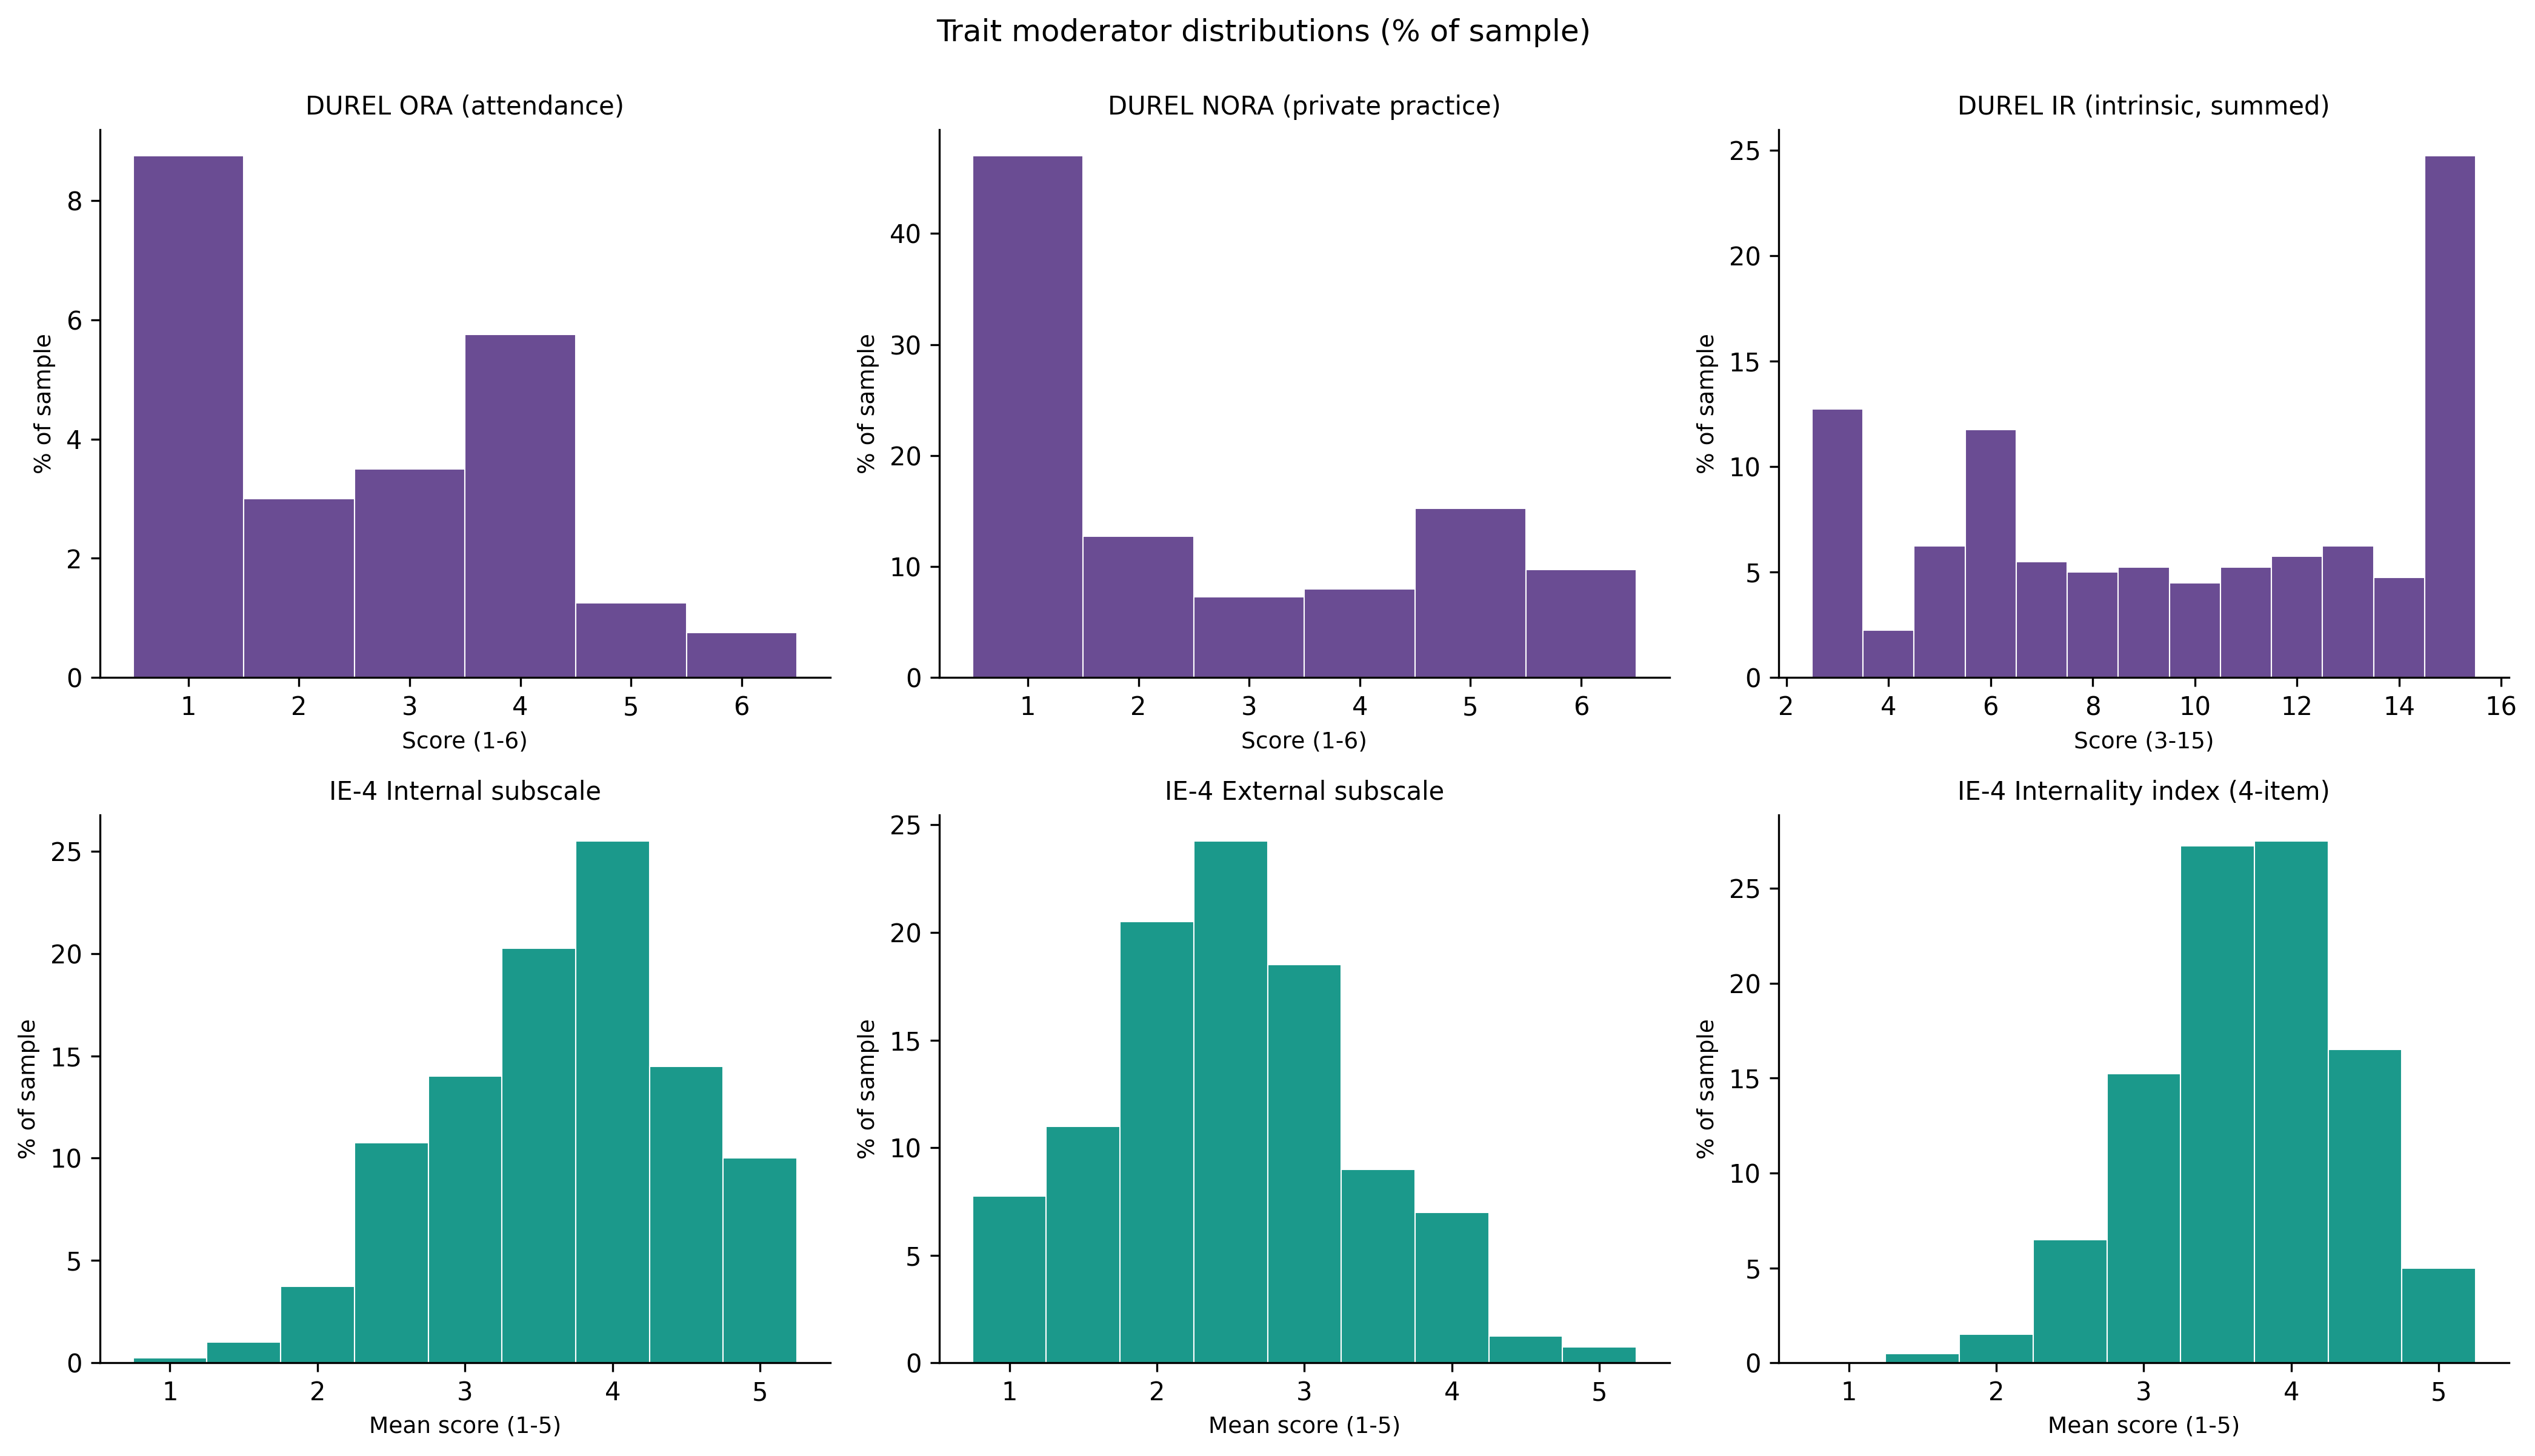

Saved: fig_moderator_dists.png


In [ ]:
# =============================================================================
# CELL 10 — DISTRIBUTION VIZ: DUREL and IE-4, y-axis = % of sample (not count)
# Weight each bar by 100/n so bar heights sum to 100% within each panel.
# DUREL IR (3-15) and internality index (1-5) get finer bins; single Likert
# items get integer bins centered on the scale points.
# =============================================================================
import numpy as np, matplotlib.pyplot as plt

d = est if 'est' in globals() else df

def pct_hist(ax, series, bins, color, title, xlabel):
    s = pd.to_numeric(series, errors='coerce').dropna()
    w = np.ones(len(s)) * 100.0 / len(s)     # each obs contributes 100/n percent
    ax.hist(s, bins=bins, weights=w, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel('% of sample', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=300)

# --- Row 1: DUREL ------------------------------------------------------------
pct_hist(axes[0, 0], d['DUREL 1_1'], np.arange(0.5, 7.5, 1), '#6A4C93',
         'DUREL ORA (attendance)', 'Score (1-6)')
pct_hist(axes[0, 1], d['DUREL 2'], np.arange(0.5, 7.5, 1), '#6A4C93',
         'DUREL NORA (private practice)', 'Score (1-6)')
pct_hist(axes[0, 2], d['durel_ir'], np.arange(2.5, 16.5, 1), '#6A4C93',
         'DUREL IR (intrinsic, summed)', 'Score (3-15)')

# --- Row 2: IE-4 -------------------------------------------------------------
pct_hist(axes[1, 0], d['ie4_internal'], np.arange(0.75, 5.5, 0.5), '#1B998B',
         'IE-4 Internal subscale', 'Mean score (1-5)')
pct_hist(axes[1, 1], d['ie4_external'], np.arange(0.75, 5.5, 0.5), '#1B998B',
         'IE-4 External subscale', 'Mean score (1-5)')
pct_hist(axes[1, 2], d['ie4_internality_index'], np.arange(0.75, 5.5, 0.5), '#1B998B',
         'IE-4 Internality index (4-item)', 'Mean score (1-5)')

fig.suptitle('Trait moderator distributions (% of sample)', y=0.995, fontsize=12)
plt.tight_layout()
plt.savefig('fig_moderator_dists.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_moderator_dists.png")

In [ ]:
print(df['DUREL 1_1'].value_counts(dropna=False).sort_index())


DUREL 1_1
0     240
1      35
2      12
3      14
4      23
5       5
6       3
7       6
8       8
9       3
10      6
11      4
12      1
14      2
15      4
16      3
19      1
20      2
21      1
22      4
23      4
24      2
25      4
28      4
29      1
31      8
Name: count, dtype: int64


In [ ]:
# =============================================================================
# CELL 11 — BALANCE TABLE across treatment arms, exported to LaTeX
# Continuous covariates: Welch ANOVA (unequal variance) -> F, p.
# Categorical covariates: Pearson chi-square of independence -> chi2, p.
# Output: booktabs + threeparttable .tex, matching the manuscript style.
# This is the List-style randomization audit; it belongs before the results.
# =============================================================================
import numpy as np, pandas as pd
try:
    import pingouin as pg
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pingouin"]); import pingouin as pg
from scipy.stats import chi2_contingency

d = est if 'est' in globals() else df
ARM_ORDER = ['Control', 'Science', 'Placebo', 'History']
d = d[d['arm_label'].isin(ARM_ORDER)].copy()

def _pcol(cols):  # version-robust p-column locator for pingouin
    for c in ['p-unc', 'p_unc', 'p']:
        if c in cols: return c
    return None

# -----------------------------------------------------------------------------
# 11.1  Continuous covariates: mean (SD) per arm + Welch ANOVA across arms.
# Add or drop rows here as the covariate set requires.
# -----------------------------------------------------------------------------
CONTINUOUS = {
    'Age (years)':                 'Age2',        # Prolific-appended age
    'Risk tolerance (0-100)':      'risk_raw',
    'DUREL IR (intrinsic, 3-15)':  'durel_ir',
    'DUREL ORA (1-6)':             'DUREL 1_1',
    'DUREL NORA (1-6)':            'DUREL 2',
    'IE-4 internality (1-5)':      'ie4_internality_index',
}

rows = []
for label, col in CONTINUOUS.items():
    cell = {}
    for arm in ARM_ORDER:
        s = pd.to_numeric(d.loc[d['arm_label'] == arm, col], errors='coerce').dropna()
        cell[arm] = f"{s.mean():.2f} ({s.std():.2f})"
    sub = d[['arm_label', col]].copy()
    sub[col] = pd.to_numeric(sub[col], errors='coerce')
    sub = sub.dropna()
    wa = pg.welch_anova(data=sub, dv=col, between='arm_label')
    pc = _pcol(wa.columns.tolist())
    F, p = wa.loc[0, 'F'], wa.loc[0, pc]
    cell.update({'stat': f"F={F:.2f}", 'p': p, 'test': 'Welch'})
    cell['Covariate'] = label
    rows.append(cell)

# -----------------------------------------------------------------------------
# 11.2  Categorical covariates: counts per arm + chi-square of independence.
# Sex and religious affiliation; collapse thin religion cells to avoid a chi2
# with many low-expected cells (report collapse in the table note).
# -----------------------------------------------------------------------------
def cat_row(label, col, collapse_map=None, min_n=15):
    v = d[col].astype(str).str.strip()
    if collapse_map is not None:
        v = v.replace(collapse_map)
    # collapse any remaining rare level into 'Other' so chi2 is well-behaved
    counts = v.value_counts()
    rare = counts[counts < min_n].index
    v = v.where(~v.isin(rare), 'Other')
    ct = pd.crosstab(d['arm_label'], v)
    chi2, p, dof, _ = chi2_contingency(ct)
    # show the modal level's share per arm as the compact cell summary
    cell = {}
    for arm in ARM_ORDER:
        n_arm = ct.loc[arm].sum() if arm in ct.index else 0
        cell[arm] = f"n={int(n_arm)}"
    cell.update({'stat': f"chi2={chi2:.2f}", 'p': p, 'test': f'chi2(df={dof})',
                 'Covariate': label})
    return cell

rows.append(cat_row('Sex', 'Sex'))
rows.append(cat_row('Religious affiliation', 'religaffil'))

bal = pd.DataFrame(rows).set_index('Covariate')
bal = bal[ARM_ORDER + ['stat', 'p', 'test']]
bal['p'] = bal['p'].astype(float)

print("Balance table (console preview):")
print(bal.assign(p=bal['p'].round(4)).to_string())

# -----------------------------------------------------------------------------
# 11.3  Emit LaTeX (booktabs + threeparttable). p formatted, no stars on a
# balance table by convention: we WANT non-significance, stars would mislead.
# -----------------------------------------------------------------------------
def fmt_p(p):
    return "$<$0.001" if p < 0.001 else f"{p:.3f}"

col_spec = "l" + "c" * len(ARM_ORDER) + "cc"
lines = []
lines.append(r"\begin{table}[htbp]")
lines.append(r"\centering")
lines.append(r"\begin{threeparttable}")
lines.append(r"\caption{Covariate balance across treatment arms}")
lines.append(r"\label{tab:balance}")
lines.append(r"\begin{tabular}{" + col_spec + "}")
lines.append(r"\toprule")
header = "Covariate & " + " & ".join(ARM_ORDER) + r" & Test & $p$ \\"
lines.append(header)
lines.append(r"\midrule")
for cov, r in bal.iterrows():
    cells = " & ".join(str(r[a]) for a in ARM_ORDER)
    lines.append(f"{cov} & {cells} & {r['stat']} & {fmt_p(r['p'])} " + r"\\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\begin{tablenotes}[flushleft]\footnotesize")
lines.append(r"\item \textit{Notes.} Continuous covariates report arm mean (SD) "
             r"with Welch's ANOVA (unequal-variance $F$). Categorical covariates "
             r"report arm $n$ with Pearson's $\chi^2$ test of independence; rare "
             r"levels collapsed to \textit{Other}. Balance is indicated by the "
             r"absence of significant arm differences.")
lines.append(r"\end{tablenotes}")
lines.append(r"\end{threeparttable}")
lines.append(r"\end{table}")
tex = "\n".join(lines)

with open('balance_table.tex', 'w') as f:
    f.write(tex)
print("\nSaved: balance_table.tex\n")
print(tex)

Balance table (console preview):
                                  Control        Science        Placebo        History        stat       p         test
Covariate                                                                                                              
Age (years)                 41.63 (13.43)  42.75 (13.24)  42.01 (12.53)  40.58 (13.86)      F=0.44  0.7236        Welch
Risk tolerance (0-100)      43.89 (24.93)  43.48 (26.53)  44.82 (23.81)  44.48 (24.78)      F=0.06  0.9824        Welch
DUREL IR (intrinsic, 3-15)    9.66 (4.19)    8.77 (4.35)   10.17 (4.35)   10.02 (4.45)      F=2.06  0.1066        Welch
DUREL ORA (1-6)               3.33 (6.52)    3.19 (6.99)    4.03 (8.13)    3.63 (7.42)      F=0.24  0.8695        Welch
DUREL NORA (1-6)              2.60 (1.76)    2.57 (1.79)    2.64 (1.96)    2.63 (1.93)      F=0.03  0.9934        Welch
IE-4 internality (1-5)        3.59 (0.67)    3.67 (0.66)    3.56 (0.66)    3.49 (0.73)      F=1.18  0.3181        Welch
Sex    

In [ ]:
# =============================================================================
# CELL 12 — COVARIATE-ADJUSTED FMLOGIT on Directed share (SECONDARY spec)
# Same fractional logit as Cell 4, now with demographic + trait controls.
# Arm AMEs remain the reported quantity; controls guard against chance imbalance
# and soak up residual variance. On a clean randomization the arm effects should
# be stable vs the unadjusted model -- that stability IS the robustness claim.
# HC3 robust VCE, Control reference, identical to the primary spec otherwise.
# =============================================================================
import numpy as np, pandas as pd
import statsmodels.api as sm, statsmodels.formula.api as smf

d = est if 'est' in globals() else df
m = d.loc[d['dir_share'].notna() & d['arm_int'].notna()].copy()

# --- 12.1  Assemble controls -------------------------------------------------
# Continuous: age, risk, religiosity (IR = the intrinsic subscale, the cleanest
# DUREL component), attendance count as a covariate per your call, IE-4 index.
# Categorical: sex, political leaning, religious affiliation (collapsed).
m['age']       = pd.to_numeric(m['Age2'], errors='coerce')     # Prolific age
m['risk']      = pd.to_numeric(m['risk_raw'], errors='coerce')
m['ir']        = pd.to_numeric(m['durel_ir'], errors='coerce')
m['attend']    = pd.to_numeric(m['DUREL 1_1'], errors='coerce')  # monthly count covariate
m['loc_int']   = pd.to_numeric(m['ie4_internality_index'], errors='coerce')

# Sex -> Male/Female/Other; collapse rare politics/affiliation levels for stability
m['sex']  = m['Sex'].astype(str).str.strip().str.capitalize()
m.loc[~m['sex'].isin(['Male', 'Female']), 'sex'] = 'Other'

def _collapse(col, min_n=15, newname='Other'):
    v = m[col].astype(str).str.strip()
    keep = v.value_counts()[lambda s: s >= min_n].index
    return v.where(v.isin(keep), newname)

m['polit'] = _collapse('politics')
m['relaff'] = _collapse('religaffil')

# arm as categorical, Control reference (identical coding to the primary spec)
m['arm_label'] = pd.Categorical(m['arm_label'],
                                categories=['Control','Science','Placebo','History'])

# --- 12.2  Listwise-complete frame; report the N drop so it is auditable ------
model_vars = ['dir_share','arm_label','age','risk','ir','attend','loc_int',
              'sex','polit','relaff']
before = len(m)
m = m.dropna(subset=model_vars).copy()
print(f"Adjusted-model N: {len(m)}  (dropped {before-len(m)} for missing covariates)")
print("Covariate missingness is the usual reason adjusted N < primary N.\n")

# --- 12.3  Fit: fractional logit (Papke-Wooldridge) with controls ------------
formula = ("dir_share ~ C(arm_label, Treatment(reference='Control')) "
           "+ age + risk + ir + attend + loc_int "
           "+ C(sex) + C(polit) + C(relaff)")
fit_adj = smf.glm(formula=formula, data=m, family=sm.families.Binomial()).fit(cov_type='HC3')
print(fit_adj.summary())

# --- 12.4  Arm AMEs (the reportable quantities), pp scale --------------------
ame = fit_adj.get_margeff(dummy=True).summary_frame()
ame = ame.rename(columns={'dy/dx':'AME','Std. Err.':'SE','z':'z','Pr(>|z|)':'p'})
ame['AME_pp'] = ame['AME']*100; ame['SE_pp'] = ame['SE']*100
arm_rows = ame.index[ame.index.str.contains('arm_label')]

print("\n" + "="*64)
print("PANEL A (HUMAN, ADJUSTED) — arm AME on Directed share vs Control")
print("="*64)
print(ame.loc[arm_rows, ['AME_pp','SE_pp','z','p']].round(4).to_string())
print("="*64)

# --- 12.5  Side-by-side: does adjustment move the arm effects? ---------------
# Pull the unadjusted arm AMEs if Cell 4's fit is still in memory.
if 'fit' in globals():
    ame0 = fit.get_margeff(dummy=True).summary_frame()
    ame0['AME_pp'] = ame0['dy/dx']*100
    comp = pd.DataFrame({
        'unadj_pp': ame0['AME_pp'].values,
        'adj_pp':   ame.loc[arm_rows,'AME_pp'].values},
        index=[i.split('T.')[-1].rstrip(']') for i in arm_rows])
    comp['shift_pp'] = comp['adj_pp'] - comp['unadj_pp']
    print("\nArm AME: unadjusted vs adjusted (pp), and the shift from controls:")
    print(comp.round(3).to_string())
    print("Small shifts => randomization held; large shifts => chance imbalance "
          "the controls are correcting.")

Adjusted-model N: 400  (dropped 0 for missing covariates)
Covariate missingness is the usual reason adjusted N < primary N.

                 Generalized Linear Model Regression Results                  
Dep. Variable:              dir_share   No. Observations:                  400
Model:                            GLM   Df Residuals:                      380
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -191.55
Date:                Tue, 25 Aug 2026   Deviance:                       124.25
Time:                        23:58:39   Pearson chi2:                     106.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.07333
Covariance Type:                  HC3                                         
                                                              coef    std err        

In [ ]:
# =============================================================================
# CELL 12 (REVISED) — COVARIATE-ADJUSTED FMLOGIT on Directed share
# Controls: age, risk, DUREL ORA (attendance count), DUREL NORA, DUREL IR,
# IE-4 internality index, and binary sex. Politics + affiliation removed.
# Arm AMEs remain the reported quantity; HC3 robust VCE; Control reference.
# =============================================================================
import numpy as np, pandas as pd
import statsmodels.api as sm, statsmodels.formula.api as smf

d = est if 'est' in globals() else df
m = d.loc[d['dir_share'].notna() & d['arm_int'].notna()].copy()

# --- 12.1  Controls ----------------------------------------------------------
m['age']     = pd.to_numeric(m['Age2'], errors='coerce')          # Prolific age
m['risk']    = pd.to_numeric(m['risk_raw'], errors='coerce')      # SOEP 0-100
m['ora']     = pd.to_numeric(m['DUREL 1_1'], errors='coerce')     # attendance count
m['nora']    = pd.to_numeric(m['DUREL 2'], errors='coerce')       # private practice 1-6
m['ir']      = pd.to_numeric(m['durel_ir'], errors='coerce')      # intrinsic 3-15
m['loc_int'] = pd.to_numeric(m['ie4_internality_index'], errors='coerce')  # 1-5

# Binary sex: female = 1 (Female), 0 (Male). Non Male/Female set to NaN so it
# drops in listwise deletion rather than being folded into either level; count
# printed below so the exclusion is auditable, not silent.
sx = m['Sex'].astype(str).str.strip().str.capitalize()
m['female'] = np.where(sx == 'Female', 1.0, np.where(sx == 'Male', 0.0, np.nan))
n_nonbinary = int(sx.isin(['Male', 'Female']).eq(False).sum())
print(f"Sex coded binary (female=1). Non Male/Female rows set NaN: {n_nonbinary}")

m['arm_label'] = pd.Categorical(m['arm_label'],
                                categories=['Control','Science','Placebo','History'])

# --- 12.2  Listwise-complete frame; report the N drop ------------------------
model_vars = ['dir_share','arm_label','age','risk','ora','nora','ir','loc_int','female']
before = len(m)
m = m.dropna(subset=model_vars).copy()
print(f"Adjusted-model N: {len(m)}  (dropped {before-len(m)} for missing covariates)\n")

# --- 12.3  Fit: fractional logit (Papke-Wooldridge) with controls ------------
formula = ("dir_share ~ C(arm_label, Treatment(reference='Control')) "
           "+ age + risk + ora + nora + ir + loc_int + female")
fit_adj = smf.glm(formula=formula, data=m, family=sm.families.Binomial()).fit(cov_type='HC3')
print(fit_adj.summary())

# --- 12.4  Arm AMEs (reportable), pp scale -----------------------------------
ame = fit_adj.get_margeff(dummy=True).summary_frame()
ame = ame.rename(columns={'dy/dx':'AME','Std. Err.':'SE','z':'z','Pr(>|z|)':'p'})
ame['AME_pp'] = ame['AME']*100; ame['SE_pp'] = ame['SE']*100
arm_rows = ame.index[ame.index.str.contains('arm_label')]

print("\n" + "="*64)
print("PANEL A (HUMAN, ADJUSTED) — arm AME on Directed share vs Control")
print("="*64)
print(ame.loc[arm_rows, ['AME_pp','SE_pp','z','p']].round(4).to_string())
print("="*64)

# --- 12.5  Unadjusted vs adjusted arm AMEs: does adjustment move them? --------
if 'fit' in globals():
    ame0 = fit.get_margeff(dummy=True).summary_frame()
    ame0['AME_pp'] = ame0['dy/dx']*100
    comp = pd.DataFrame({
        'unadj_pp': ame0['AME_pp'].values,
        'adj_pp':   ame.loc[arm_rows,'AME_pp'].values},
        index=[i.split('T.')[-1].rstrip(']') for i in arm_rows])
    comp['shift_pp'] = comp['adj_pp'] - comp['unadj_pp']
    print("\nArm AME: unadjusted vs adjusted (pp), shift from controls:")
    print(comp.round(3).to_string())

Sex coded binary (female=1). Non Male/Female rows set NaN: 0
Adjusted-model N: 400  (dropped 0 for missing covariates)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              dir_share   No. Observations:                  400
Model:                            GLM   Df Residuals:                      389
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -193.79
Date:                Tue, 25 Aug 2026   Deviance:                       128.73
Time:                        23:58:39   Pearson chi2:                     110.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06289
Covariance Type:                  HC3                                         
                                                              coef    std err          z  

In [ ]:
# Descriptives: mean (SD) allocations by arm + demographics for balance table
alloc = dfh.groupby('arm')[['directed','undirected','unknowable']].agg(['mean','std']).round(2)
print(alloc.reindex(['control','science','placebo','history']))

dfh['Age_n'] = pd.to_numeric(dfh['Age'], errors='coerce')
demo = dfh.groupby('arm').agg(
    age_mean=('Age_n','mean'),
    female_pct=('Sex', lambda s: (s.astype(str).str.lower()=='female').mean()*100),
).round(2)
print(demo.reindex(['control','science','placebo','history']))
print(dfh.groupby('arm')['politics'].value_counts())   # eyeball; we'll summarize

        directed        undirected        unknowable       
            mean    std       mean    std       mean    std
arm                                                        
control    40.74  18.08      29.32  19.83      29.94  17.36
science    38.35  34.04      31.22  27.96      30.43  26.27
placebo    41.69  35.60      30.69  26.69      27.62  25.44
history    42.13  19.65      28.31  21.07      29.56  17.43
         age_mean  female_pct
arm                          
control     41.50        58.0
science     42.77        42.0
placebo     42.07        51.0
history     40.46        55.0
arm      politics
control  50          23
         90           7
         100          7
         10           4
         40           4
                     ..
science  75           1
         79           1
         87           1
         89           1
         94           1
Name: count, Length: 182, dtype: int64


In [ ]:
# =============================================================================
# CELL 3 — COVARIATE BALANCE TABLE (human cohort, corrected data)
# Diagnoses DUREL ORA out-of-range codes, computes Welch's ANOVA for continuous
# covariates and Pearson chi2 for categorical, prints LaTeX rows.
# =============================================================================
import numpy as np, pandas as pd
from scipy.stats import chi2_contingency, f as f_dist

ARM_ORDER = ['control', 'science', 'placebo', 'history']

# ---------------------------------------------------------------- DUREL mapping
# Standard Koenig DUREL: item 1 = ORA (attendance, 1-6), item 2 = NORA
# (private activity, 1-6), items 3-5 = IR (intrinsic, each 1-5, summed 3-15).
# Header names in this file: 'DUREL 1_1' -> ORA, 'DUREL 2' -> NORA,
# 'durel 3_1'..'durel 3_3' -> IR items. Verify with the diagnostics below.
print("=== DUREL raw value diagnostics (look for codes outside scale range) ===")
for col, expect in [('DUREL 1_1', '1-6 (ORA)'), ('DUREL 2', '1-6 (NORA)'),
                    ('durel 3_1', '1-5'), ('durel 3_2', '1-5'), ('durel 3_3', '1-5')]:
    v = pd.to_numeric(dfh[col], errors='coerce')
    print(f"{col:<12} expect {expect:<12} min={v.min()} max={v.max()} "
          f"| values: {sorted(v.dropna().unique())}")

def clean_scale(col, lo, hi):
    """Numeric coercion + set out-of-range codes to NaN, report how many."""
    v = pd.to_numeric(dfh[col], errors='coerce')
    bad = ((v < lo) | (v > hi)).sum()
    if bad:
        print(f"  -> {col}: {bad} out-of-range value(s) set to NaN")
    return v.where((v >= lo) & (v <= hi))

print("\n=== Cleaning ===")
dfh['ORA']   = clean_scale('DUREL 1_1', 1, 6)
dfh['NORA']  = clean_scale('DUREL 2', 1, 6)
ir_items     = [clean_scale(c, 1, 5) for c in ['durel 3_1','durel 3_2','durel 3_3']]
dfh['IR']    = sum(ir_items)                       # 3-15, NaN if any item missing
dfh['Age_n'] = pd.to_numeric(dfh['Age'], errors='coerce')
dfh['Risk']  = pd.to_numeric(dfh['RiskBattery_1'], errors='coerce')
dfh['Pol']   = pd.to_numeric(dfh['politics'], errors='coerce')
ie_items     = [clean_scale(c, 1, 5) for c in
                ['IE-4 LOC_1','IE-4 LOC_2','IE-4 LOC_3','IE-4 LOC_5']]
# IE-4: items 1-2 internal, 3-4 external. Internality = mean of first two.
dfh['IE_int'] = (ie_items[0] + ie_items[1]) / 2

# ------------------------------------------------------------- Welch's ANOVA
def welch_anova(series):
    groups = [series[dfh['arm'] == a].dropna().values for a in ARM_ORDER]
    k = len(groups)
    n = np.array([len(g) for g in groups], float)
    m = np.array([g.mean() for g in groups])
    v = np.array([g.var(ddof=1) for g in groups])
    w = n / v
    mw = (w * m).sum() / w.sum()
    A = (w * (m - mw)**2).sum() / (k - 1)
    B = 1 + (2*(k-2)/(k**2-1)) * ((1/(n-1)) * (1 - w/w.sum())**2).sum()
    F = A / B
    df2 = (k**2 - 1) / (3 * ((1/(n-1)) * (1 - w/w.sum())**2).sum())
    p = 1 - f_dist.cdf(F, k-1, df2)
    return F, p

def cont_row(label, col, dec=2):
    parts = []
    for a in ARM_ORDER:
        g = dfh.loc[dfh['arm'] == a, col].dropna()
        parts.append(f"{g.mean():.{dec}f} ({g.std(ddof=1):.{dec}f})")
    F, p = welch_anova(dfh[col])
    print(f"{label:<28} " + " | ".join(parts) + f"  F={F:.2f}, p={p:.3f}")
    return (f"{label} & " + " & ".join(parts) +
            f" & $F$={F:.2f} & {p:.3f} \\\\")

def cat_row(label, col, collapse_min=10):
    s = dfh[col].astype(str).str.strip()
    counts = s.value_counts()
    rare = counts[counts < collapse_min].index
    s = s.where(~s.isin(rare), 'Other')
    tab = pd.crosstab(s, dfh['arm'])[ARM_ORDER]
    chi2, p, dof, _ = chi2_contingency(tab)
    print(f"{label:<28} levels={list(tab.index)}  chi2({dof})={chi2:.2f}, p={p:.3f}")
    return (f"{label} & \\multicolumn{{4}}{{c}}{{$n=100$ per arm}} "
            f"& $\\chi^2({dof})$={chi2:.2f} & {p:.3f} \\\\")

print("\n=== Balance statistics (corrected data) ===")
rows = []
rows.append(cont_row("Age (years)", 'Age_n'))
rows.append(cont_row("Political ideology (0--100)", 'Pol'))
rows.append(cont_row("Risk tolerance (0--100)", 'Risk'))
rows.append(cont_row("DUREL IR (intrinsic, 3--15)", 'IR'))
rows.append(cont_row("DUREL ORA (1--6)", 'ORA'))
rows.append(cont_row("DUREL NORA (1--6)", 'NORA'))
rows.append(cont_row("IE-4 internality (1--5)", 'IE_int'))
rows.append(cat_row("Sex", 'Sex'))
rows.append(cat_row("Religious affiliation", 'religaffil'))

print("\n% ---- paste into tab:balance ----")
print("\n".join(rows))

# Joint balance check: F-test that arm assignment is unpredictable
print("\nFemale % by arm:",
      dfh.groupby('arm')['Sex'].apply(
          lambda s: (s.astype(str).str.lower()=='female').mean()*100
      ).round(1).reindex(ARM_ORDER).to_dict())

=== DUREL raw value diagnostics (look for codes outside scale range) ===
DUREL 1_1    expect 1-6 (ORA)    min=0 max=31 | values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(28), np.int64(29), np.int64(31)]
DUREL 2      expect 1-6 (NORA)   min=1 max=6 | values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
durel 3_1    expect 1-5          min=1 max=5 | values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
durel 3_2    expect 1-5          min=1 max=5 | values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
durel 3_3    expect 1-5          min=1 max=5 | values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

=== Cleaning ===
 

Now I'm adding additional covariant to the human regressions for robustness

In [ ]:
# =============================================================================
# CELL 2b — HUMAN FMLOGIT WITH DUREL + LoC CONTROLS
# Extends Cell 2: same QMLE estimator, same seed-307302 bootstrap.
# Produces treatment AMEs with AND without controls on the SAME analytic
# sample, plus per-SD covariate partial associations. All three shares.
# =============================================================================
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm

SEED = 307302
B    = 400

# ---- rebuild dfh exactly as in Cell 2 (junk strip, alloc map, arm harmonize) --
dfh = df.copy()
dur = pd.to_numeric(dfh['Duration (in seconds)'], errors='coerce')
dfh = dfh[dur.notna()].reset_index(drop=True)
dfh = dfh.rename(columns={'allocate1':'directed','allocate2':'undirected','allocate3':'unknowable'})
for c in ['directed','undirected','unknowable']:
    dfh[c] = pd.to_numeric(dfh[c])
dfh['arm'] = pd.to_numeric(dfh['arm']).map({1:'control',2:'science',3:'placebo',4:'history'})
ARMS = ['science','placebo','history']
assert set(dfh['arm'].unique()) == {'control','science','placebo','history'}
assert (dfh[['directed','undirected','unknowable']].sum(1) != 100).sum() == 0
assert dfh['PID'].duplicated().sum() == 0

# ---- NEW: covariate construction ---------------------------------------------
COV_RAW = {'ORA':'DUREL 1_1', 'NORA':'DUREL 2',
           'IR1':'durel 3_1', 'IR2':'durel 3_2', 'IR3':'durel 3_3',
           'LOC1':'IE-4 LOC_1', 'LOC2':'IE-4 LOC_2',
           'LOC3':'IE-4 LOC_3', 'LOC5':'IE-4 LOC_5'}
for k,v in COV_RAW.items():
    dfh[k] = pd.to_numeric(dfh[v], errors='coerce')
dfh['IR'] = dfh[['IR1','IR2','IR3']].sum(axis=1, min_count=3)   # 3-15, NaN if any item missing

COV_BASE = ['ORA','NORA','IR','LOC1','LOC2','LOC3','LOC5']       # LOC entered item-wise, no reverse-coding
dfa = dfh.dropna(subset=COV_BASE).copy()                         # listwise on covariates
for c in COV_BASE:                                              # standardize ONCE on analytic sample
    dfa[c+'_z'] = (dfa[c] - dfa[c].mean()) / dfa[c].std(ddof=1)
COVARS = [c+'_z' for c in COV_BASE]
print(f"Full human N: {len(dfh)}  |  covariate-complete analytic N: {len(dfa)}  "
      f"(dropped {len(dfh)-len(dfa)} on missing DUREL/LoC)")
print(dfa['arm'].value_counts().to_dict())

S_a = dfa[['directed','undirected','unknowable']].values / 100.0

# ---- estimator (unchanged) ----------------------------------------------------
def fit_fmlogit(Xmat, Smat):
    n, k = Xmat.shape
    def negqll_grad(theta):
        b = theta.reshape(2, k)
        eta = np.column_stack([Xmat @ b.T, np.zeros(n)])
        mx = eta.max(1, keepdims=True)
        ex = np.exp(eta - mx); p = ex / ex.sum(1, keepdims=True)
        f = -(Smat * np.log(np.clip(p, 1e-12, 1))).sum()
        g = np.empty((2, k))
        for j in range(2):
            g[j] = Xmat.T @ (p[:, j] - Smat[:, j])
        return f, g.ravel()
    res = minimize(negqll_grad, np.zeros(2*k), jac=True, method='L-BFGS-B',
                   options={'maxiter':20000,'maxfun':50000,'ftol':1e-12,'gtol':1e-8})
    return res.x.reshape(2, k), res

def predict_all(Xmat, beta):
    eta = np.column_stack([Xmat @ beta.T, np.zeros(len(Xmat))])
    mx = eta.max(1, keepdims=True)
    p = np.exp(eta - mx); p /= p.sum(1, keepdims=True)
    return p                                   # cols: directed, undirected, unknowable

# ---- CHANGED: build_design and ame_table thread an optional covariate block ---
def build_design(data, arms=ARMS, covars=None):
    cols = [np.ones(len(data))]; names = ['const']
    for a in arms:
        cols.append((data['arm'] == a).astype(float).values); names.append(f'arm_{a}')
    if covars:
        for c in covars:
            cols.append(data[c].astype(float).values); names.append(c)
    return np.column_stack(cols), names

def ame_table(data, beta, covars=None):
    base = data.copy(); base['arm'] = 'control'
    p0 = predict_all(build_design(base, covars=covars)[0], beta).mean(0)
    out = {}
    for a in ARMS:
        cf = data.copy(); cf['arm'] = a
        out[a] = (predict_all(build_design(cf, covars=covars)[0], beta).mean(0) - p0) * 100
    return out

# ---- NEW: per-SD covariate partial associations (central difference) ----------
def covariate_ame(data, beta, covars, delta=0.5):     # z-scored covars, so +/-0.5 = 1 SD span
    out = {}
    for c in covars:
        hi = data.copy(); hi[c] = hi[c] + delta
        lo = data.copy(); lo[c] = lo[c] - delta
        out[c] = (predict_all(build_design(hi, covars=covars)[0], beta).mean(0)
                  - predict_all(build_design(lo, covars=covars)[0], beta).mean(0)) * 100
    return out

# ---- point fits: base vs controlled on the SAME analytic sample ---------------
beta_base, r0 = fit_fmlogit(build_design(dfa)[0], S_a)
beta_ctrl, r1 = fit_fmlogit(build_design(dfa, covars=COVARS)[0], S_a)
print("converged  base:", r0.success, " controlled:", r1.success)
ame_base = ame_table(dfa, beta_base)
ame_ctrl = ame_table(dfa, beta_ctrl, covars=COVARS)
cov_ame  = covariate_ame(dfa, beta_ctrl, COVARS)

# ---- bootstrap: both models on each resample, seed-307302 ---------------------
rng = np.random.default_rng(SEED)
bb = {a:[] for a in ARMS}; bc = {a:[] for a in ARMS}; bv = {c:[] for c in COVARS}
n = len(dfa); fails = 0
for _ in range(B):
    idx = rng.integers(0, n, n)
    d_b = dfa.iloc[idx].reset_index(drop=True)
    S_b = d_b[['directed','undirected','unknowable']].values / 100.0
    beta0, rb0 = fit_fmlogit(build_design(d_b)[0], S_b)
    beta1, rb1 = fit_fmlogit(build_design(d_b, covars=COVARS)[0], S_b)
    if not (rb0.success and rb1.success):
        fails += 1; continue
    ab, ac = ame_table(d_b, beta0), ame_table(d_b, beta1, covars=COVARS)
    av = covariate_ame(d_b, beta1, COVARS)
    for a in ARMS: bb[a].append(ab[a]); bc[a].append(ac[a])
    for c in COVARS: bv[c].append(av[c])
print(f"bootstrap: {B-fails}/{B} successful")

# ---- report -------------------------------------------------------------------
CATS = ['Directed','Undirected','Unknowable']
def star(p): return "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else ""

def show(title, ames, boot):
    print("\n" + "="*80); print(title); print("="*80)
    print(f"{'arm':<10}" + "".join(f"{c:>23}" for c in CATS))
    for a in ARMS:
        se = np.array(boot[a]).std(0, ddof=1)
        p  = 2*(1-norm.cdf(np.abs(ames[a]/se)))
        print(f"{a:<10} " + "  ".join(f"{ames[a][j]:+7.2f} ({se[j]:.2f}){star(p[j]):<3}" for j in range(3)))

show("PANEL A HUMAN — treatment AMEs vs Control, NO controls  (analytic sample)", ame_base, bb)
show("PANEL A' HUMAN — treatment AMEs vs Control, +DUREL +LoC (analytic sample)", ame_ctrl, bc)

print("\n" + "="*80)
print("COVARIATE PARTIAL ASSOCIATIONS — AME per 1 SD on each share (controlled model)")
print("="*80)
print(f"{'covariate':<10}" + "".join(f"{c:>23}" for c in CATS))
for c in COVARS:
    se = np.array(bv[c]).std(0, ddof=1)
    p  = 2*(1-norm.cdf(np.abs(cov_ame[c]/se)))
    print(f"{c:<10} " + "  ".join(f"{cov_ame[c][j]:+7.2f} ({se[j]:.2f}){star(p[j]):<3}" for j in range(3)))

for a in ARMS:
    print(f"sum-to-zero  {a:<8} base {ame_base[a].sum():+.3f}  ctrl {ame_ctrl[a].sum():+.3f}")

Full human N: 400  |  covariate-complete analytic N: 400  (dropped 0 on missing DUREL/LoC)
{'placebo': 100, 'history': 100, 'control': 100, 'science': 100}
converged  base: True  controlled: True
bootstrap: 400/400 successful

PANEL A HUMAN — treatment AMEs vs Control, NO controls  (analytic sample)
arm                      Directed             Undirected             Unknowable
science      -2.39 (3.82)       +1.90 (3.64)       +0.49 (3.12)   
placebo      +0.95 (4.10)       +1.37 (3.44)       -2.32 (3.09)   
history      +1.39 (2.60)       -1.01 (2.92)       -0.38 (2.53)   

PANEL A' HUMAN — treatment AMEs vs Control, +DUREL +LoC (analytic sample)
arm                      Directed             Undirected             Unknowable
science      -3.23 (3.18)       +2.41 (3.36)       +0.82 (3.05)   
placebo      +1.29 (3.47)       +0.82 (2.96)       -2.12 (2.93)   
history      +1.67 (2.88)       -1.72 (2.94)       +0.04 (2.56)   

COVARIATE PARTIAL ASSOCIATIONS — AME per 1 SD on each share (

In [ ]:
# =============================================================================
# CELL 2c — HUMAN FMLOGIT: THREE PANELS
#   A   base (no controls)
#   A'  + DUREL + LoC
#   A'' + DUREL + LoC + demographics (sex, age, politics) + SOEP risk
# Same QMLE estimator, same seed-307302 bootstrap. All three shares.
# =============================================================================
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm

SEED, B = 307302, 400

# ---- rebuild dfh (junk strip, alloc map, arm harmonize) ----------------------
dfh = df.copy()
dfh = dfh[pd.to_numeric(dfh['Duration (in seconds)'], errors='coerce').notna()].reset_index(drop=True)
dfh = dfh.rename(columns={'allocate1':'directed','allocate2':'undirected','allocate3':'unknowable'})
for c in ['directed','undirected','unknowable']:
    dfh[c] = pd.to_numeric(dfh[c])
dfh['arm'] = pd.to_numeric(dfh['arm']).map({1:'control',2:'science',3:'placebo',4:'history'})
ARMS = ['science','placebo','history']
assert set(dfh['arm'].unique()) == {'control','science','placebo','history'}
assert (dfh[['directed','undirected','unknowable']].sum(1) != 100).sum() == 0
assert dfh['PID'].duplicated().sum() == 0

# ---- religiosity + LoC (as before) -------------------------------------------
COV_RAW = {'ORA':'DUREL 1_1','NORA':'DUREL 2','IR1':'durel 3_1','IR2':'durel 3_2','IR3':'durel 3_3',
           'LOC1':'IE-4 LOC_1','LOC2':'IE-4 LOC_2','LOC3':'IE-4 LOC_3','LOC5':'IE-4 LOC_5'}
for k,v in COV_RAW.items():
    dfh[k] = pd.to_numeric(dfh[v], errors='coerce')
dfh['IR'] = dfh[['IR1','IR2','IR3']].sum(axis=1, min_count=3)
COV_BASE = ['ORA','NORA','IR','LOC1','LOC2','LOC3','LOC5']

# ---- NEW: demographics + risk ------------------------------------------------
dfh['age']      = pd.to_numeric(dfh['Age'], errors='coerce')          # col 50, not Age2
dfh['politics'] = pd.to_numeric(dfh['politics'], errors='coerce')     # direction uninterpreted (control only)
dfh['risk']     = pd.to_numeric(dfh['RiskBattery_1'], errors='coerce')# SOEP 0-100 slider
sex_raw = dfh['Sex'].astype(str).str.strip().str.lower()
print("Sex raw values:", sex_raw.value_counts().to_dict())            # eyeball this
dfh['female'] = np.where(sex_raw.eq('female'), 1.0,
                np.where(sex_raw.eq('male'),   0.0, np.nan))           # non-binary/expired -> NaN -> listwise
DEMO_CONT = ['age','politics','risk']

# ---- single analytic sample: complete on EVERY covariate ---------------------
REQUIRED = COV_BASE + DEMO_CONT + ['female']
dfa = dfh.dropna(subset=REQUIRED).copy()
for c in COV_BASE + DEMO_CONT:                                        # standardize once on analytic sample
    dfa[c+'_z'] = (dfa[c] - dfa[c].mean()) / dfa[c].std(ddof=1)
COVARS_REL  = [c+'_z' for c in COV_BASE]
COVARS_DEMO = ['female','age_z','politics_z','risk_z']                # female left 0/1
COVARS_FULL = COVARS_REL + COVARS_DEMO
print(f"Full N: {len(dfh)}  |  analytic N (all covariates complete): {len(dfa)} "
      f"(dropped {len(dfh)-len(dfa)})")
print(dfa['arm'].value_counts().to_dict())
S_a = dfa[['directed','undirected','unknowable']].values / 100.0

# ---- estimator ----------------------------------------------------------------
def fit_fmlogit(Xmat, Smat):
    n, k = Xmat.shape
    def negqll_grad(theta):
        b = theta.reshape(2, k)
        eta = np.column_stack([Xmat @ b.T, np.zeros(n)])
        mx = eta.max(1, keepdims=True); ex = np.exp(eta - mx); p = ex / ex.sum(1, keepdims=True)
        f = -(Smat * np.log(np.clip(p, 1e-12, 1))).sum()
        g = np.empty((2, k))
        for j in range(2): g[j] = Xmat.T @ (p[:, j] - Smat[:, j])
        return f, g.ravel()
    res = minimize(negqll_grad, np.zeros(2*k), jac=True, method='L-BFGS-B',
                   options={'maxiter':20000,'maxfun':50000,'ftol':1e-12,'gtol':1e-8})
    return res.x.reshape(2, k), res

def predict_all(Xmat, beta):
    eta = np.column_stack([Xmat @ beta.T, np.zeros(len(Xmat))])
    mx = eta.max(1, keepdims=True); p = np.exp(eta - mx); p /= p.sum(1, keepdims=True)
    return p

def build_design(data, arms=ARMS, covars=None):
    cols = [np.ones(len(data))]; names = ['const']
    for a in arms:
        cols.append((data['arm'] == a).astype(float).values); names.append(f'arm_{a}')
    if covars:
        for c in covars:
            cols.append(data[c].astype(float).values); names.append(c)
    return np.column_stack(cols), names

def ame_table(data, beta, covars=None):
    base = data.copy(); base['arm'] = 'control'
    p0 = predict_all(build_design(base, covars=covars)[0], beta).mean(0)
    out = {}
    for a in ARMS:
        cf = data.copy(); cf['arm'] = a
        out[a] = (predict_all(build_design(cf, covars=covars)[0], beta).mean(0) - p0) * 100
    return out

def covariate_ame(data, beta, covars, binary=('female',), delta=0.5):
    out = {}
    for c in covars:
        hi = data.copy(); lo = data.copy()
        if c in binary: hi[c], lo[c] = 1.0, 0.0                        # discrete male->female
        else:           hi[c], lo[c] = hi[c]+delta, lo[c]-delta        # per 1 SD (z-scored)
        out[c] = (predict_all(build_design(hi, covars=covars)[0], beta).mean(0)
                  - predict_all(build_design(lo, covars=covars)[0], beta).mean(0)) * 100
    return out

# ---- point fits: base / +rel / +rel+demo -------------------------------------
beta_base, r0 = fit_fmlogit(build_design(dfa)[0], S_a)
beta_rel,  r1 = fit_fmlogit(build_design(dfa, covars=COVARS_REL)[0],  S_a)
beta_full, r2 = fit_fmlogit(build_design(dfa, covars=COVARS_FULL)[0], S_a)
print("converged  base:", r0.success, " rel:", r1.success, " full:", r2.success)
ame_base = ame_table(dfa, beta_base)
ame_rel  = ame_table(dfa, beta_rel,  covars=COVARS_REL)
ame_full = ame_table(dfa, beta_full, covars=COVARS_FULL)
cov_ame  = covariate_ame(dfa, beta_full, COVARS_FULL)

# ---- bootstrap: all three per resample ---------------------------------------
rng = np.random.default_rng(SEED)
bb = {a:[] for a in ARMS}; br = {a:[] for a in ARMS}; bf = {a:[] for a in ARMS}
bv = {c:[] for c in COVARS_FULL}
n = len(dfa); fails = 0
for _ in range(B):
    idx = rng.integers(0, n, n)
    d_b = dfa.iloc[idx].reset_index(drop=True)
    S_b = d_b[['directed','undirected','unknowable']].values / 100.0
    b0, s0 = fit_fmlogit(build_design(d_b)[0], S_b)
    b1, s1 = fit_fmlogit(build_design(d_b, covars=COVARS_REL)[0],  S_b)
    b2, s2 = fit_fmlogit(build_design(d_b, covars=COVARS_FULL)[0], S_b)
    if not (s0.success and s1.success and s2.success): fails += 1; continue
    a0, a1, a2 = ame_table(d_b, b0), ame_table(d_b, b1, covars=COVARS_REL), ame_table(d_b, b2, covars=COVARS_FULL)
    av = covariate_ame(d_b, b2, COVARS_FULL)
    for a in ARMS: bb[a].append(a0[a]); br[a].append(a1[a]); bf[a].append(a2[a])
    for c in COVARS_FULL: bv[c].append(av[c])
print(f"bootstrap: {B-fails}/{B} successful")

# ---- report ------------------------------------------------------------------
CATS = ['Directed','Undirected','Unknowable']
def star(p): return "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else ""
def show(title, ames, boot):
    print("\n" + "="*80); print(title); print("="*80)
    print(f"{'arm':<10}" + "".join(f"{c:>23}" for c in CATS))
    for a in ARMS:
        se = np.array(boot[a]).std(0, ddof=1); p = 2*(1-norm.cdf(np.abs(ames[a]/se)))
        print(f"{a:<10} " + "  ".join(f"{ames[a][j]:+7.2f} ({se[j]:.2f}){star(p[j]):<3}" for j in range(3)))

show("PANEL A   HUMAN — treatment AMEs vs Control, NO controls",            ame_base, bb)
show("PANEL A'  HUMAN — + DUREL + LoC",                                      ame_rel,  br)
show("PANEL A'' HUMAN — + DUREL + LoC + demographics + risk",               ame_full, bf)

print("\n" + "="*80)
print("COVARIATE PARTIAL ASSOCIATIONS (full model) — per 1 SD; female = male->female")
print("="*80)
print(f"{'covariate':<11}" + "".join(f"{c:>23}" for c in CATS))
for c in COVARS_FULL:
    se = np.array(bv[c]).std(0, ddof=1); p = 2*(1-norm.cdf(np.abs(cov_ame[c]/se)))
    print(f"{c:<11} " + "  ".join(f"{cov_ame[c][j]:+7.2f} ({se[j]:.2f}){star(p[j]):<3}" for j in range(3)))

for a in ARMS:
    print(f"sum-to-zero {a:<8} base {ame_base[a].sum():+.3f}  rel {ame_rel[a].sum():+.3f}  full {ame_full[a].sum():+.3f}")

Sex raw values: {'female': 206, 'male': 194}
Full N: 400  |  analytic N (all covariates complete): 400 (dropped 0)
{'placebo': 100, 'history': 100, 'control': 100, 'science': 100}
converged  base: True  rel: True  full: True
bootstrap: 400/400 successful

PANEL A   HUMAN — treatment AMEs vs Control, NO controls
arm                      Directed             Undirected             Unknowable
science      -2.39 (3.82)       +1.90 (3.64)       +0.49 (3.12)   
placebo      +0.95 (4.10)       +1.37 (3.44)       -2.32 (3.09)   
history      +1.39 (2.60)       -1.01 (2.92)       -0.38 (2.53)   

PANEL A'  HUMAN — + DUREL + LoC
arm                      Directed             Undirected             Unknowable
science      -3.23 (3.18)       +2.41 (3.36)       +0.82 (3.05)   
placebo      +1.29 (3.47)       +0.82 (2.96)       -2.12 (2.93)   
history      +1.67 (2.88)       -1.72 (2.94)       +0.04 (2.56)   

PANEL A'' HUMAN — + DUREL + LoC + demographics + risk
arm                      Directed    

You were talking about norms it's not gonna be a centerpiece of the analysis, but we get a little bit of perceptions in reality here in humans and we're keeping it because it was technically pre-register

N = 400

OVERALL   perceived (mean guess): 52.8%   reality (majority-Directed): 34.8%   mean signed error: +18.0 pp

--- BY ARM ---
arm         n  guess mean  guess sd   true %  error(pp)
-------------------------------------------------------
control   100        51.5      18.6     38.0       13.5
science   100        49.2      20.3     33.0       16.2
placebo   100        54.0      20.8     34.0       20.0
history   100        56.4      21.0     34.0       22.4

Kruskal-Wallis  EE1 (guess) across arms: H=5.46, p=0.141
Wilcoxon  signed error != 0: W=9124, p=0.0000

Projection:  Spearman(guess, own Directed tokens) rho=+0.23, p=0.000
             Spearman(guess, own majority-Directed) rho=+0.21, p=0.000


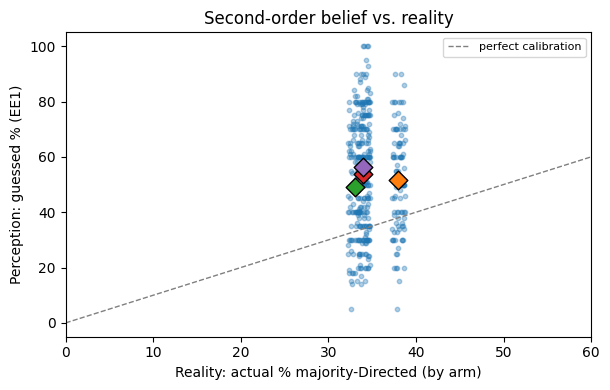

In [ ]:
# =============================================================================
# CELL 3 (CORRECTED) — EE1 AS INCENTIVIZED SECOND-ORDER BELIEF (0-100)
# EE1 = guess: "of 100 who read this same material, what % placed the MAJORITY
#       of tokens on Directed?"  Incentivized (bonus if within 5 pts).
# Reality (per arm) = actual % who placed majority on Directed (directed > 50).
# Perception vs reality, calibration error, and self-projection.
# =============================================================================
import numpy as np
from scipy.stats import kruskal, spearmanr, wilcoxon

d = df.copy()
d = d[pd.to_numeric(d['Duration (in seconds)'], errors='coerce').notna()].reset_index(drop=True)
d = d.rename(columns={'allocate1':'directed','allocate2':'undirected','allocate3':'unknowable'})
for c in ['directed','undirected','unknowable']:
    d[c] = pd.to_numeric(d[c])
d['arm'] = pd.to_numeric(d['arm']).map({1:'control',2:'science',3:'placebo',4:'history'})
d['EE1'] = pd.to_numeric(d['EE1'], errors='coerce')     # 0-100 guess about others
ORDER = ['control','science','placebo','history']

d = d.dropna(subset=['EE1']).copy()
assert d['EE1'].between(0,100).all(), "EE1 out of 0-100 range"
d['maj_directed'] = (d['directed'] > 50).astype(int)    # reality indicator (self)

# reality rate per arm, then merge each subject's guess against THEIR arm's truth
truth = d.groupby('arm')['maj_directed'].mean().mul(100).rename('true_rate')
d = d.join(truth, on='arm')
d['error'] = d['EE1'] - d['true_rate']                  # signed calibration error (perceived - actual)

print(f"N = {len(d)}")
print(f"\nOVERALL   perceived (mean guess): {d['EE1'].mean():.1f}%   "
      f"reality (majority-Directed): {100*d['maj_directed'].mean():.1f}%   "
      f"mean signed error: {d['error'].mean():+.1f} pp")

print("\n--- BY ARM ---")
hdr = f"{'arm':<9}{'n':>4}{'guess mean':>12}{'guess sd':>10}{'true %':>9}{'error(pp)':>11}"
print(hdr); print("-"*len(hdr))
for a in ORDER:
    s = d[d['arm']==a]
    print(f"{a:<9}{len(s):>4}{s['EE1'].mean():>12.1f}{s['EE1'].std():>10.1f}"
          f"{s['true_rate'].iloc[0]:>9.1f}{s['error'].mean():>11.1f}")

# does the SECOND-ORDER BELIEF move across arms, even though allocations didn't?
H, p = kruskal(*[d.loc[d['arm']==a,'EE1'].values for a in ORDER])
print(f"\nKruskal-Wallis  EE1 (guess) across arms: H={H:.2f}, p={p:.3f}")

# is the overall over/under-estimate significant? (paired: guess vs own arm truth)
w, pw = wilcoxon(d['error'])
print(f"Wilcoxon  signed error != 0: W={w:.0f}, p={pw:.4f}")

# self-projection / false consensus: own bet vs guess about others
r1,p1 = spearmanr(d['EE1'], d['directed'])
r2,p2 = spearmanr(d['EE1'], d['maj_directed'])
print(f"\nProjection:  Spearman(guess, own Directed tokens) rho={r1:+.2f}, p={p1:.3f}")
print(f"             Spearman(guess, own majority-Directed) rho={r2:+.2f}, p={p2:.3f}")

# calibration scatter: each subject's guess vs their arm's true rate
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.2,4))
jit = (np.random.default_rng(0).random(len(d))-0.5)*1.5
ax.scatter(d['true_rate']+jit, d['EE1'], s=10, alpha=0.35)
for a in ORDER:
    s=d[d['arm']==a]; ax.scatter(s['true_rate'].iloc[0], s['EE1'].mean(), s=90, marker='D', edgecolor='k', zorder=5)
lims=[0,100]; ax.plot(lims,lims,'--',color='gray',lw=1,label='perfect calibration')
ax.set_xlabel('Reality: actual % majority-Directed (by arm)')
ax.set_ylabel('Perception: guessed % (EE1)')
ax.set_title('Second-order belief vs. reality'); ax.legend(fontsize=8); ax.set_xlim(0,60)
plt.tight_layout(); plt.show()

In [ ]:
# ---- MODE of the second-order belief (EE1 guess) ----------------------------
# Slider guesses often pile on round numbers (50, 75), so the mode is more telling
# than the mean here. mode() returns all tied values; we show them and their count.
def modes(x):
    vc = x.value_counts()
    top = vc.max()
    vals = sorted(vc[vc == top].index.tolist())
    return vals, int(top)

mvals, mcount = modes(d['EE1'])
print(f"\nOVERALL EE1 mode: {mvals}  (appears {mcount}x of {len(d)}; "
      f"mean {d['EE1'].mean():.1f}, median {d['EE1'].median():.1f})")

print("\n--- EE1 MODE BY ARM ---")
for a in ORDER:
    s = d.loc[d['arm']==a, 'EE1']
    mv, mc = modes(s)
    print(f"{a:<9} mode {str(mv):<14} ({mc}/{len(s)})   mean {s.mean():.1f}  median {s.median():.1f}")

# full guess distribution (round-number clustering check)
print("\nEE1 value counts (top 10):")
print(d['EE1'].value_counts().head(10).sort_index().to_dict())


OVERALL EE1 mode: [60]  (appears 32x of 400; mean 52.8, median 52.0)

--- EE1 MODE BY ARM ---
control   mode [50, 60]       (9/100)   mean 51.5  median 50.0
science   mode [40]           (11/100)   mean 49.2  median 50.0
placebo   mode [30]           (10/100)   mean 54.0  median 51.0
history   mode [60]           (13/100)   mean 56.4  median 60.0

EE1 value counts (top 10):
{30: 28, 35: 17, 40: 30, 45: 13, 50: 22, 60: 32, 65: 14, 70: 21, 75: 13, 80: 22}


In [ ]:
# Which category got each person's LARGEST share? (plurality, not majority)
alloc = d[['directed','undirected','unknowable']]
winner = alloc.idxmax(axis=1)                       # ties -> first listed (directed>undirected>unknowable)
ties = (alloc.max(axis=1).values[:,None] == alloc.values).sum(axis=1) > 1
print("Plurality winner, share of people:")
print((winner.value_counts(normalize=True)*100).round(1).to_dict())
print(f"(rows with a tie at the top: {ties.sum()})")

# and the arm breakdown, since that's the version that goes in a table
print("\nBy arm:")
print(pd.crosstab(d['arm'], winner, normalize='index').mul(100).round(1)
        .reindex(ORDER)[['directed','undirected','unknowable']])

Plurality winner, share of people:
{'directed': 44.5, 'undirected': 29.5, 'unknowable': 26.0}
(rows with a tie at the top: 32)

By arm:
col_0    directed  undirected  unknowable
arm                                      
control      45.0        27.0        28.0
science      40.0        35.0        25.0
placebo      48.0        27.0        25.0
history      45.0        29.0        26.0


In [ ]:
print(df.columns.tolist())
print(df.shape)
df.head()

['IPAddress', 'Duration (in seconds)', 'RecordedDate', 'ResponseId', 'LocationLatitude', 'LocationLongitude', 'PID', 'treatment', 'read timer_First Click', 'read timer_Last Click', 'read timer_Page Submit', 'read timer_Click Count', 'exp timer_First Click', 'exp timer_Last Click', 'exp timer_Page Submit', 'exp timer_Click Count', 'allocate1', 'allocate2', 'allocate3', 'timer token First Click', 'timer token Last Click', 'timer token Page Submit', 'timer token Click Count', 'why', 'timer why First Click', 'timerwhyLast Click', 'timerwhyPage Submit', 'timer whyClick Count', 'mancheck1', 'norms', 'norms timer_First Click', 'norms timer_Last Click', 'norms timer_Page Submit', 'norms timer_Click Count', 'EE1', 'belief timer First Click', 'belief timer Last Click', 'belief timer Page Submit', 'belief timer Click Count', 'RiskBattery_1', 'IE-4 LOC_1', 'IE-4 LOC_2', 'IE-4 LOC_3', 'IE-4 LOC_5', 'DUREL 1_1', 'DUREL 2', 'durel 3_1', 'durel 3_2', 'durel 3_3', 'heart', 'Age', 'politics', 'religaffi

,IPAddress,Duration (in seconds),RecordedDate,ResponseId,LocationLatitude,LocationLongitude,PID,treatment,read timer_First Click,read timer_Last Click,...,unk_share,durel_ora,durel_nora,durel_ir,durel_total,ie4_internal,ie4_external,ie4_internality_index,risk_raw,risk_soep10
285,139.62.222.198,135,8/24/26 10:58,R_1zKot5MlJCXsRwZ,30.3007,-81.4421,6a04c82110b7006966082469,placebo,3.413,4.951,...,0.20,0,1,12,13,4.0,3.5,3.25,51,5.1
323,68.96.215.195,139,8/24/26 10:58,R_10wQrc3uKR2GRXQ,36.2819,-115.1475,62c4dbae8fb1ff9cd93a3150,history,0.000,0.000,...,0.48,5,6,3,14,4.0,3.5,3.25,63,6.3
279,76.206.246.99,219,8/24/26 10:59,R_1xFkellwH2e0exb,41.9210,-87.6454,69fe16b6ff0a21017cb119bc,placebo,0.000,0.000,...,0.00,15,3,6,24,4.0,3.5,3.25,40,4.0
90,107.77.208.204,234,8/24/26 10:59,R_725Zkv6l3zSpwHk,41.8483,-87.6517,6a0ccf4fae3b8559e2c08556,c,0.907,11.543,...,0.42,4,2,14,20,3.5,3.0,3.25,16,1.6
315,174.74.50.141,202,8/24/26 10:59,R_1bzAYHLKlgP7C3n,41.2120,-96.1101,600db78b56935a5dd8c759b3,history,4.433,4.433,...,0.19,0,6,15,21,4.0,2.5,3.75,1,0.1


In [ ]:
from scipy import stats
from itertools import combinations

DIR_COL = 'allocate1'
ARM_COL = 'arm_label'

groups = [g[DIR_COL].values for _, g in df.groupby(ARM_COL)]

W, p = stats.levene(*groups, center='median')
print(f"Brown-Forsythe W = {W:.3f}, p = {p:.4f}")

# sanity: SDs should match tab:descriptives (Control ~18.1, Science ~34.0, Placebo ~35.6, History ~19.7)
print(df.groupby(ARM_COL)[DIR_COL].agg(['mean', 'std', 'count']))

for a, b in combinations([g for g, _ in df.groupby(ARM_COL)], 2):
    ga = df.loc[df[ARM_COL] == a, DIR_COL].values
    gb = df.loc[df[ARM_COL] == b, DIR_COL].values
    w, pp = stats.levene(ga, gb, center='median')
    print(f"{a:8s} vs {b:8s}: W={w:5.2f}  p={pp:.4f}")

Brown-Forsythe W = 23.807, p = 0.0000
            mean        std  count
arm_label                         
Control    40.74  18.078739    100
History    42.13  19.649276    100
Placebo    41.69  35.602092    100
Science    38.35  34.038711    100
Control  vs History : W= 0.73  p=0.3934
Control  vs Placebo : W=45.02  p=0.0000
Control  vs Science : W=33.36  p=0.0000
History  vs Placebo : W=37.03  p=0.0000
History  vs Science : W=26.66  p=0.0000
Placebo  vs Science : W= 0.49  p=0.4865


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

ARM = 'arm_label'
ORA_COL = 'durel_ora'   # confirmed: the 0-31 attendance count

d = df[[ARM, ORA_COL]].copy()
d[ORA_COL] = pd.to_numeric(d[ORA_COL], errors='coerce')
d = d.dropna(subset=[ORA_COL])

# By-arm mean / SD / n
print(d.groupby(ARM)[ORA_COL].agg(['mean', 'std', 'count']).round(3))

# Welch's unequal-variance ANOVA (matches the table's stated test)
try:
    import pingouin as pg
    w = pg.welch_anova(data=d, dv=ORA_COL, between=ARM)
    print("\nWelch ANOVA:")
    print(w.round(4).to_string(index=False))
except ImportError:
    groups = [g[ORA_COL].values for _, g in d.groupby(ARM)]
    F, p = stats.f_oneway(*groups)
    print(f"\nClassic one-way ANOVA (install pingouin for Welch): F={F:.3f}, p={p:.4f}")

           mean    std  count
arm_label                    
Control    3.33  6.523    100
History    3.63  7.415    100
Placebo    4.03  8.135    100
Science    3.19  6.995    100

Welch ANOVA:
   Source  ddof1    ddof2      F  p_unc   np2
arm_label      3 219.3832 0.2384 0.8695 0.002


In [ ]:
d2 = df[[ARM, 'durel_nora']].copy()
d2['durel_nora'] = pd.to_numeric(d2['durel_nora'], errors='coerce')
d2 = d2.dropna(subset=['durel_nora'])
print(d2.groupby(ARM)['durel_nora'].agg(['mean','std','count']).round(3))
import pingouin as pg
print(pg.welch_anova(data=d2, dv='durel_nora', between=ARM).round(4).to_string(index=False))

           mean    std  count
arm_label                    
Control    2.60  1.758    100
History    2.63  1.926    100
Placebo    2.64  1.957    100
Science    2.57  1.788    100
   Source  ddof1    ddof2      F  p_unc    np2
arm_label      3 219.7934 0.0288 0.9934 0.0002


In [ ]:
d3 = df[[ARM, 'durel_ir']].copy()
d3['durel_ir'] = pd.to_numeric(d3['durel_ir'], errors='coerce')
d3 = d3.dropna(subset=['durel_ir'])
print(d3.groupby(ARM)['durel_ir'].agg(['mean','std']).round(2))


            mean   std
arm_label             
Control     9.66  4.19
History    10.02  4.45
Placebo    10.17  4.35
Science     8.77  4.35
